In [1]:
import os
import torch
import torch.nn as nn
import pickle
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import pearsonr
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
)

# **Load saved model and setups**

In [2]:
# ================================================================
# Load the saved model and prepare the external validation data
# ================================================================

# ----------------------------------------------------------------
# 0) File paths
# ----------------------------------------------------------------
CKPT_PATH = "twohead_model_checkpoint.pt"
ART_PATH = "twohead_model_artifacts.pkl"
VAL_PATH = "Data_val.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ----------------------------------------------------------------
# 1) Load artifacts and checkpoint
# ----------------------------------------------------------------
with open(ART_PATH, "rb") as f:
    art = pickle.load(f)

# Load the saved training information.
FEAT_COLS = art["FEAT_COLS"]               # input feature order
OUT_COLS = art["OUT_COLS"]                 # output protein order
NUM_IDX = art["NUM_IDX"]                   # numeric feature indices
scaler = art["scaler_final"]               # scaler fitted on training data
id_to_name = art["id_to_name"]             # UniProt ID -> protein name
id_to_cat = art["id_to_cat"]               # UniProt ID -> functional category
CATEGORY_ORDER = art["CATEGORY_ORDER"]      # fixed category order
audit_df = art["audit_df"]                  # protein counts by category

# Load the saved model checkpoint.
ckpt = torch.load(
    CKPT_PATH,
    map_location=device,
    weights_only=False,
)

cfg = ckpt["best_cfg"]          # best hyperparameters
IN_DIM = ckpt["in_dim"]         # number of input features
K_TOTAL = ckpt["k_total"]       # number of model outputs

# Check that checkpoint and artifacts match.
assert IN_DIM == len(FEAT_COLS)
assert K_TOTAL == len(OUT_COLS)


# ----------------------------------------------------------------
# 2) Define the model structure
# ----------------------------------------------------------------
# This must match the training model exactly.
STOPGRAD_GATE = True


class MLP(nn.Module):

    def __init__(self, in_dim, widths, dropout=0.0):
        super().__init__()

        layers = []
        d = in_dim

        for w in widths:
            layers.append(nn.Linear(d, w))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            d = w

        self.net = nn.Sequential(*layers)
        self.out_dim = d

    def forward(self, x):
        return self.net(x)


class TwoHead(nn.Module):
    """Shared encoder with presence and abundance heads."""

    def __init__(
        self,
        in_dim,
        hidden,
        k,
        dropout,
        alpha_gate,
        temp_init,
    ):
        super().__init__()

        self.enc = MLP(in_dim, hidden, dropout)

        H = self.enc.out_dim

        # Predict protein presence.
        self.pres = nn.Linear(H, k)

        # Predict protein abundance.
        self.abun = nn.Linear(H, k)

        # Control the presence gate strength.
        self.alpha = nn.Parameter(
            torch.tensor(float(alpha_gate))
        )

        # Control the softmax temperature.
        self.temp = nn.Parameter(
            torch.tensor(float(temp_init))
        )

    def forward(self, x):

        # Extract shared features.
        z = self.enc(x)

        # Predict presence and abundance logits.
        pres_logits = self.pres(z)
        abund_logits = self.abun(z)

        # Stop the abundance loss from updating the presence head.
        if STOPGRAD_GATE:
            gate_input = pres_logits.detach()
        else:
            gate_input = pres_logits

        # Convert presence logits into a soft gate.
        gate = torch.sigmoid(
            self.alpha * gate_input
        )

        # Reduce abundance for proteins with low presence.
        masked = abund_logits + torch.log(
            gate + 1e-8
        )

        # Keep the temperature in a stable range.
        T = self.temp.clamp(0.5, 5.0)

        # Convert abundance logits into a log-probability distribution.
        abund_logprob = F.log_softmax(
            masked / T,
            dim=1,
        )

        return pres_logits, abund_logprob


# Build the model with the saved hyperparameters.
model = TwoHead(
    in_dim=IN_DIM,
    hidden=cfg["HIDDEN"],
    k=K_TOTAL,
    dropout=cfg["DROPOUT"],
    alpha_gate=cfg["ALPHA"],
    temp_init=cfg["TEMP_INIT"],
).to(device)

# Load the saved model weights.
model.load_state_dict(
    ckpt["model_state_dict"]
)

# Switch to evaluation mode.
model.eval()


# ----------------------------------------------------------------
# 3) Preprocess validation features
# ----------------------------------------------------------------
# Define the order of ordinal features.
ORDINAL_ORDER = {
    "incub_time": ["<30", "30~60", ">60"],
    "washing_steps": ["1~3", "4~6", "Not Reported"],
}

# These categorical features are one-hot encoded.
NOMINAL_COLS = [
    "mod_type",
    "mod_charge",
    "np_type",
    "np_subtype",
    "zp_charge",
    "zp_solvent",
    "hd_solvent",
    "agitation",
]

# These continuous features are standardized.
NUMERIC_COLS = [
    "size_nm",
    "zp_mv",
]

# Load the external validation dataset.
df = pd.read_csv(VAL_PATH)

X = pd.DataFrame(index=df.index)


# Convert numeric features to numbers.
for c in NUMERIC_COLS:
    X[c] = pd.to_numeric(
        df[c],
        errors="coerce",
    )

# Fill missing numeric values with the validation median.
X[NUMERIC_COLS] = (
    X[NUMERIC_COLS]
    .fillna(X[NUMERIC_COLS].median())
)


# Convert ordinal categories into numeric codes.
for c, order in ORDINAL_ORDER.items():

    mapping = {
        v: i for i, v in enumerate(order)
    }

    codes = df[c].map(mapping)

    # Unknown values are mapped to the lowest level.
    if codes.isna().any():

        bad_values = df.loc[
            codes.isna(),
            c,
        ].unique()

        print(
            f"[WARN] Unknown ordinal value(s) in '{c}': "
            f"{bad_values} -> mapped to lowest level (0)."
        )

    X[c] = codes.fillna(0).astype(float)


# One-hot encode nominal features.
dummies = pd.get_dummies(
    df[NOMINAL_COLS].astype(str),
    dummy_na=False,
).astype(float)

X = pd.concat(
    [X, dummies],
    axis=1,
)


# Find validation categories that were not seen during training.
unseen = [
    c for c in X.columns
    if c not in FEAT_COLS
]

if unseen:
    print(
        f"[WARN] {len(unseen)} one-hot column(s) "
        "not in training, dropped:"
    )
    print("       ", unseen)


# Match the exact training feature order.
X = X.reindex(
    columns=FEAT_COLS,
    fill_value=0.0,
)

Xv = X.values.astype(
    np.float32
).copy()


# Standardize numeric features with the training scaler.
Xv[:, NUM_IDX] = scaler.transform(
    Xv[:, NUM_IDX]
)

# Check that no missing values remain.
assert not np.isnan(Xv).any(), (
    "NaN found in validation feature matrix."
)


# ----------------------------------------------------------------
# 4) Build validation targets
# ----------------------------------------------------------------
y_raw_cols = {}

# Exclude the pooled OTHER output from the protein panel.
panel_proteins_all = [
    c for c in OUT_COLS
    if c != "OTHER"
]

overlap_idx_list = []     # detected proteins in validation
missing_in_val = []       # proteins missing from validation
all_zero_in_val = []      # proteins present but always zero
overlap_records = []


for out_i, out_id in enumerate(OUT_COLS):

    # Match the model output to the validation column name.
    if out_id == "OTHER":
        val_col = "OTHER"
    else:
        val_col = id_to_name.get(
            out_id,
            out_id,
        )

    # Use the validation column if it exists.
    if val_col in df.columns:

        vals = pd.to_numeric(
            df[val_col],
            errors="coerce",
        )

        # Missing or negative abundance is set to zero.
        vals = (
            vals
            .fillna(0.0)
            .clip(lower=0.0)
        )

        y_raw_cols[out_id] = vals.to_numpy(
            dtype=np.float64
        )

        if out_id != "OTHER":

            # Keep proteins with detected abundance.
            if vals.sum() > 0:
                overlap_idx_list.append(out_i)
                status = "overlap_detected"

            # Record proteins that are always zero.
            else:
                all_zero_in_val.append(out_id)
                status = "all_zero_in_validation"

            overlap_records.append({
                "UniProt_ID": out_id,
                "Protein_name": val_col,
                "Status": status,
                "Total_abundance_in_val": float(vals.sum()),
            })

    # Fill missing protein columns with zero.
    else:

        y_raw_cols[out_id] = np.zeros(
            len(df),
            dtype=np.float64,
        )

        if out_id != "OTHER":

            missing_in_val.append(out_id)

            overlap_records.append({
                "UniProt_ID": out_id,
                "Protein_name": val_col,
                "Status": "missing_from_validation",
                "Total_abundance_in_val": 0.0,
            })


# Assemble targets in the model output order.
Y_raw_df = pd.DataFrame(
    y_raw_cols,
    index=df.index,
)

Y_raw_df = Y_raw_df.reindex(
    columns=OUT_COLS,
    fill_value=0.0,
).copy()

Y_raw = Y_raw_df[
    OUT_COLS
].values.astype(np.float64)


# Calculate the total abundance for each NP.
row_sum = Y_raw.sum(
    axis=1,
    keepdims=True,
)

# Each NP must contain at least one detected protein.
if np.any(row_sum <= 0):

    bad_rows = np.where(
        row_sum.flatten() <= 0
    )[0]

    raise ValueError(
        "Some validation samples have zero total target abundance: "
        f"rows {bad_rows.tolist()}"
    )


# Normalize abundance so each NP sums to 1.
Y_abund = Y_raw / row_sum

# Presence is 1 when protein abundance is greater than zero.
Y_pres = (
    Y_raw > 0.0
).astype(int)


# Use detected overlapping proteins for validation metrics.
panel_idx_list = overlap_idx_list

if len(panel_idx_list) == 0:
    raise ValueError(
        "No overlapping detected proteins were found "
        "in validation data."
    )


# Report protein overlap between model and validation data.
print("\n=== Protein overlap check ===")
print(
    f"Model panel proteins        : "
    f"{len(panel_proteins_all)}"
)
print(
    f"Detected overlap in val     : "
    f"{len(panel_idx_list)}"
)
print(
    f"All-zero in validation      : "
    f"{len(all_zero_in_val)}"
)
print(
    f"Missing from validation     : "
    f"{len(missing_in_val)}"
)


# Save the protein overlap information.
overlap_df = pd.DataFrame(
    overlap_records
)

overlap_df.to_csv(
    "external_protein_overlap_check.csv",
    index=False,
)


# ----------------------------------------------------------------
# 5) Run model inference
# ----------------------------------------------------------------
with torch.no_grad():

    # Convert validation features to a tensor.
    xb = torch.from_numpy(
        Xv
    ).to(device)

    # Run the model once.
    pres_logits, abund_logprob = model(xb)

    # Convert presence logits into probabilities.
    P_pres = torch.sigmoid(
        pres_logits
    ).cpu().numpy()

    # Convert log-probabilities into abundance probabilities.
    P_abund = torch.exp(
        abund_logprob
    ).cpu().numpy()


print(
    f"\n[Cell done] N = {len(df)} NPs, "
    f"K = {K_TOTAL} outputs, "
    f"overlap = {len(panel_idx_list)} proteins."
)

[WARN] 1 one-hot column(s) not in training, dropped:
        ['mod_type_Surfactant']

=== Protein overlap check ===
Model panel proteins        : 174
Detected overlap in val     : 124
All-zero in validation      : 50
Missing from validation     : 0

[Cell done] N = 8 NPs, K = 175 outputs, overlap = 124 proteins.


# **Validation**

In [3]:
# ================================================================
# Evaluate external validation performance on overlap proteins
# ================================================================

# ----------------------------------------------------------------
# 0) Keep overlap proteins and renormalize abundance
# ----------------------------------------------------------------
SUB = list(panel_idx_list)                   # indices in OUT_COLS
sub_ids = [OUT_COLS[i] for i in SUB]         # overlap UniProt IDs
N_SUB = len(sub_ids)                         # number of overlap proteins
N = Y_abund.shape[0]                         # number of validation NPs
EPS = 1e-12

print(
    f"[info] Using {N_SUB} overlap proteins across "
    f"{N} NPs for metrics."
)


def _renorm(mat_full):
    # Keep only overlap proteins.
    sub = mat_full[:, SUB].astype(np.float64)

    # Calculate the total abundance for each NP.
    row = sub.sum(axis=1, keepdims=True)

    # Avoid division by zero.
    safe = np.where(row > EPS, row, 1.0)

    # Renormalize each NP to sum to 1.
    return sub / safe


# Renormalize predicted and observed abundance.
Pred_ab = _renorm(P_abund)
Obs_ab = _renorm(Y_abund)

# Keep presence probabilities for overlap proteins.
Pred_pr_prob = P_pres[:, SUB].astype(np.float64)

# Presence is predicted when probability is at least 0.5.
Pred_pr = (Pred_pr_prob >= 0.5).astype(int)

# Observed presence is 1 when abundance is greater than zero.
Obs_pr = (Y_pres[:, SUB] > 0).astype(int)


# ----------------------------------------------------------------
# 1) Map proteins to functional categories
# ----------------------------------------------------------------
def _category_of(pid):
    # Use Other/Mixed when the category is unknown.
    cat = id_to_cat.get(pid, "Other/Mixed")

    return (
        cat
        if cat in CATEGORY_ORDER
        else "Other/Mixed"
    )


# Count overlap proteins with a known category.
_hit = sum(
    1 for pid in sub_ids
    if pid in id_to_cat
)

print(
    f"[id_to_cat] mapped {_hit}/{N_SUB} overlap proteins "
    "to a real category (rest -> Other/Mixed)"
)


# Group local protein indices by category.
cat_to_local = {
    c: [] for c in CATEGORY_ORDER
}

for local_j, pid in enumerate(sub_ids):
    cat_to_local[
        _category_of(pid)
    ].append(local_j)


# ----------------------------------------------------------------
# 2) Metric helpers
# ----------------------------------------------------------------
def _f1_only(cols):
    # Calculate presence F1 for selected proteins.
    if len(cols) == 0:
        return {
            "N": 0,
            "F1": np.nan,
        }

    yt = Obs_pr[:, cols]
    yp = Pred_pr[:, cols]

    # Macro-F1 is calculated across the NP-protein matrix.
    return {
        "N": len(cols),
        "F1": round(
            f1_score(
                yt,
                yp,
                average="macro",
                zero_division=0,
            ),
            2,
        ),
    }


def _cosine_only(cols):
    # Calculate abundance cosine similarity for selected proteins.
    if len(cols) == 0:
        return {
            "N": 0,
            "Cosine": np.nan,
        }

    yt = Obs_ab[:, cols]
    yp = Pred_ab[:, cols]

    # Calculate the dot product for each NP.
    num = (yt * yp).sum(axis=1)

    # Calculate the product of vector lengths.
    den = (
        np.linalg.norm(yt, axis=1)
        * np.linalg.norm(yp, axis=1)
    )

    # Cosine similarity = dot product / product of lengths.
    cos = num / np.clip(
        den,
        EPS,
        None,
    )

    return {
        "N": len(cols),
        "Cosine": round(
            float(cos.mean()),
            2,
        ),
    }


# ----------------------------------------------------------------
# 3) Define category order
# ----------------------------------------------------------------
# Keep only categories found in the overlap proteins.
_present_cats = [
    c for c in CATEGORY_ORDER
    if len(cat_to_local[c]) > 0
]

# Sort categories alphabetically and keep Other/Mixed last.
_sorted_cats = sorted(
    _present_cats,
    key=lambda c: (
        c == "Other/Mixed",
        c.lower(),
    ),
)


# ----------------------------------------------------------------
# 4) Build the validation summary table
# ----------------------------------------------------------------
all_cols = list(range(N_SUB))

rows = []


# Calculate overall performance using all overlap proteins.
f1_all = _f1_only(all_cols)
cos_all = _cosine_only(all_cols)

rows.append({
    "Category": "Overall",
    "N": f1_all["N"],
    "F1 (Presence Head)": f1_all["F1"],
    "Cosine (Abundance Head)": cos_all["Cosine"],
})


# Calculate performance for each functional category.
for c in _sorted_cats:

    cols = cat_to_local[c]

    f1_c = _f1_only(cols)
    cos_c = _cosine_only(cols)

    rows.append({
        "Category": c,
        "N": f1_c["N"],
        "F1 (Presence Head)": f1_c["F1"],
        "Cosine (Abundance Head)": cos_c["Cosine"],
    })


# Create the final summary table.
summary_df = (
    pd.DataFrame(rows)
    .set_index("Category")[
        [
            "N",
            "F1 (Presence Head)",
            "Cosine (Abundance Head)",
        ]
    ]
)


# Print the validation results.
print("\n" + "=" * 62)
print(
    f"  Performance of model external validation "
    f"({N_SUB} proteins)"
)
print("=" * 62)

print(
    summary_df.to_string(
        float_format=lambda x: f"{x:.2f}"
    )
)


# Save the validation summary.
summary_df.to_csv(
    "external_validation_summary.csv",
    float_format="%.2f",
)


# ----------------------------------------------------------------
# 5) Prepare category composition for plotting
# ----------------------------------------------------------------
def composition_by_category(vec_sub):
    # Initialize all functional categories.
    out = {
        c: 0.0
        for c in CATEGORY_ORDER
    }

    # Sum protein abundance within each category.
    for local_j, pid in enumerate(sub_ids):
        out[
            _category_of(pid)
        ] += float(vec_sub[local_j])

    return out


# Store predicted and observed compositions for each NP.
pie_data = {}

for i in range(N):

    np_id = df["NP_ID"].iloc[i]

    pie_data[np_id] = {
        "predicted_protein": Pred_ab[i],
        "observed_protein": Obs_ab[i],
        "predicted_category": composition_by_category(
            Pred_ab[i]
        ),
        "observed_category": composition_by_category(
            Obs_ab[i]
        ),
        "protein_ids": sub_ids,
    }

[info] Using 124 overlap proteins across 8 NPs for metrics.
[id_to_cat] mapped 124/124 overlap proteins to a real category (rest -> Other/Mixed)

  Performance of model external validation (124 proteins)
                          N  F1 (Presence Head)  Cosine (Abundance Head)
Category                                                                
Overall                 124                0.76                     0.77
Apolipoproteins          14                0.81                     0.91
Coagulation/Fibrinogen   13                0.76                     0.69
Complement System        17                0.74                     0.81
Cytoskeletal             13                0.75                     0.43
Immunoglobulins           8                0.59                     0.51
Metabolic Enzymes         6                0.76                     0.49
Protease/Inhibitors      13                0.80                     0.73
Transport/Binding        26                0.76                   

# **Grouped circular bar plot**

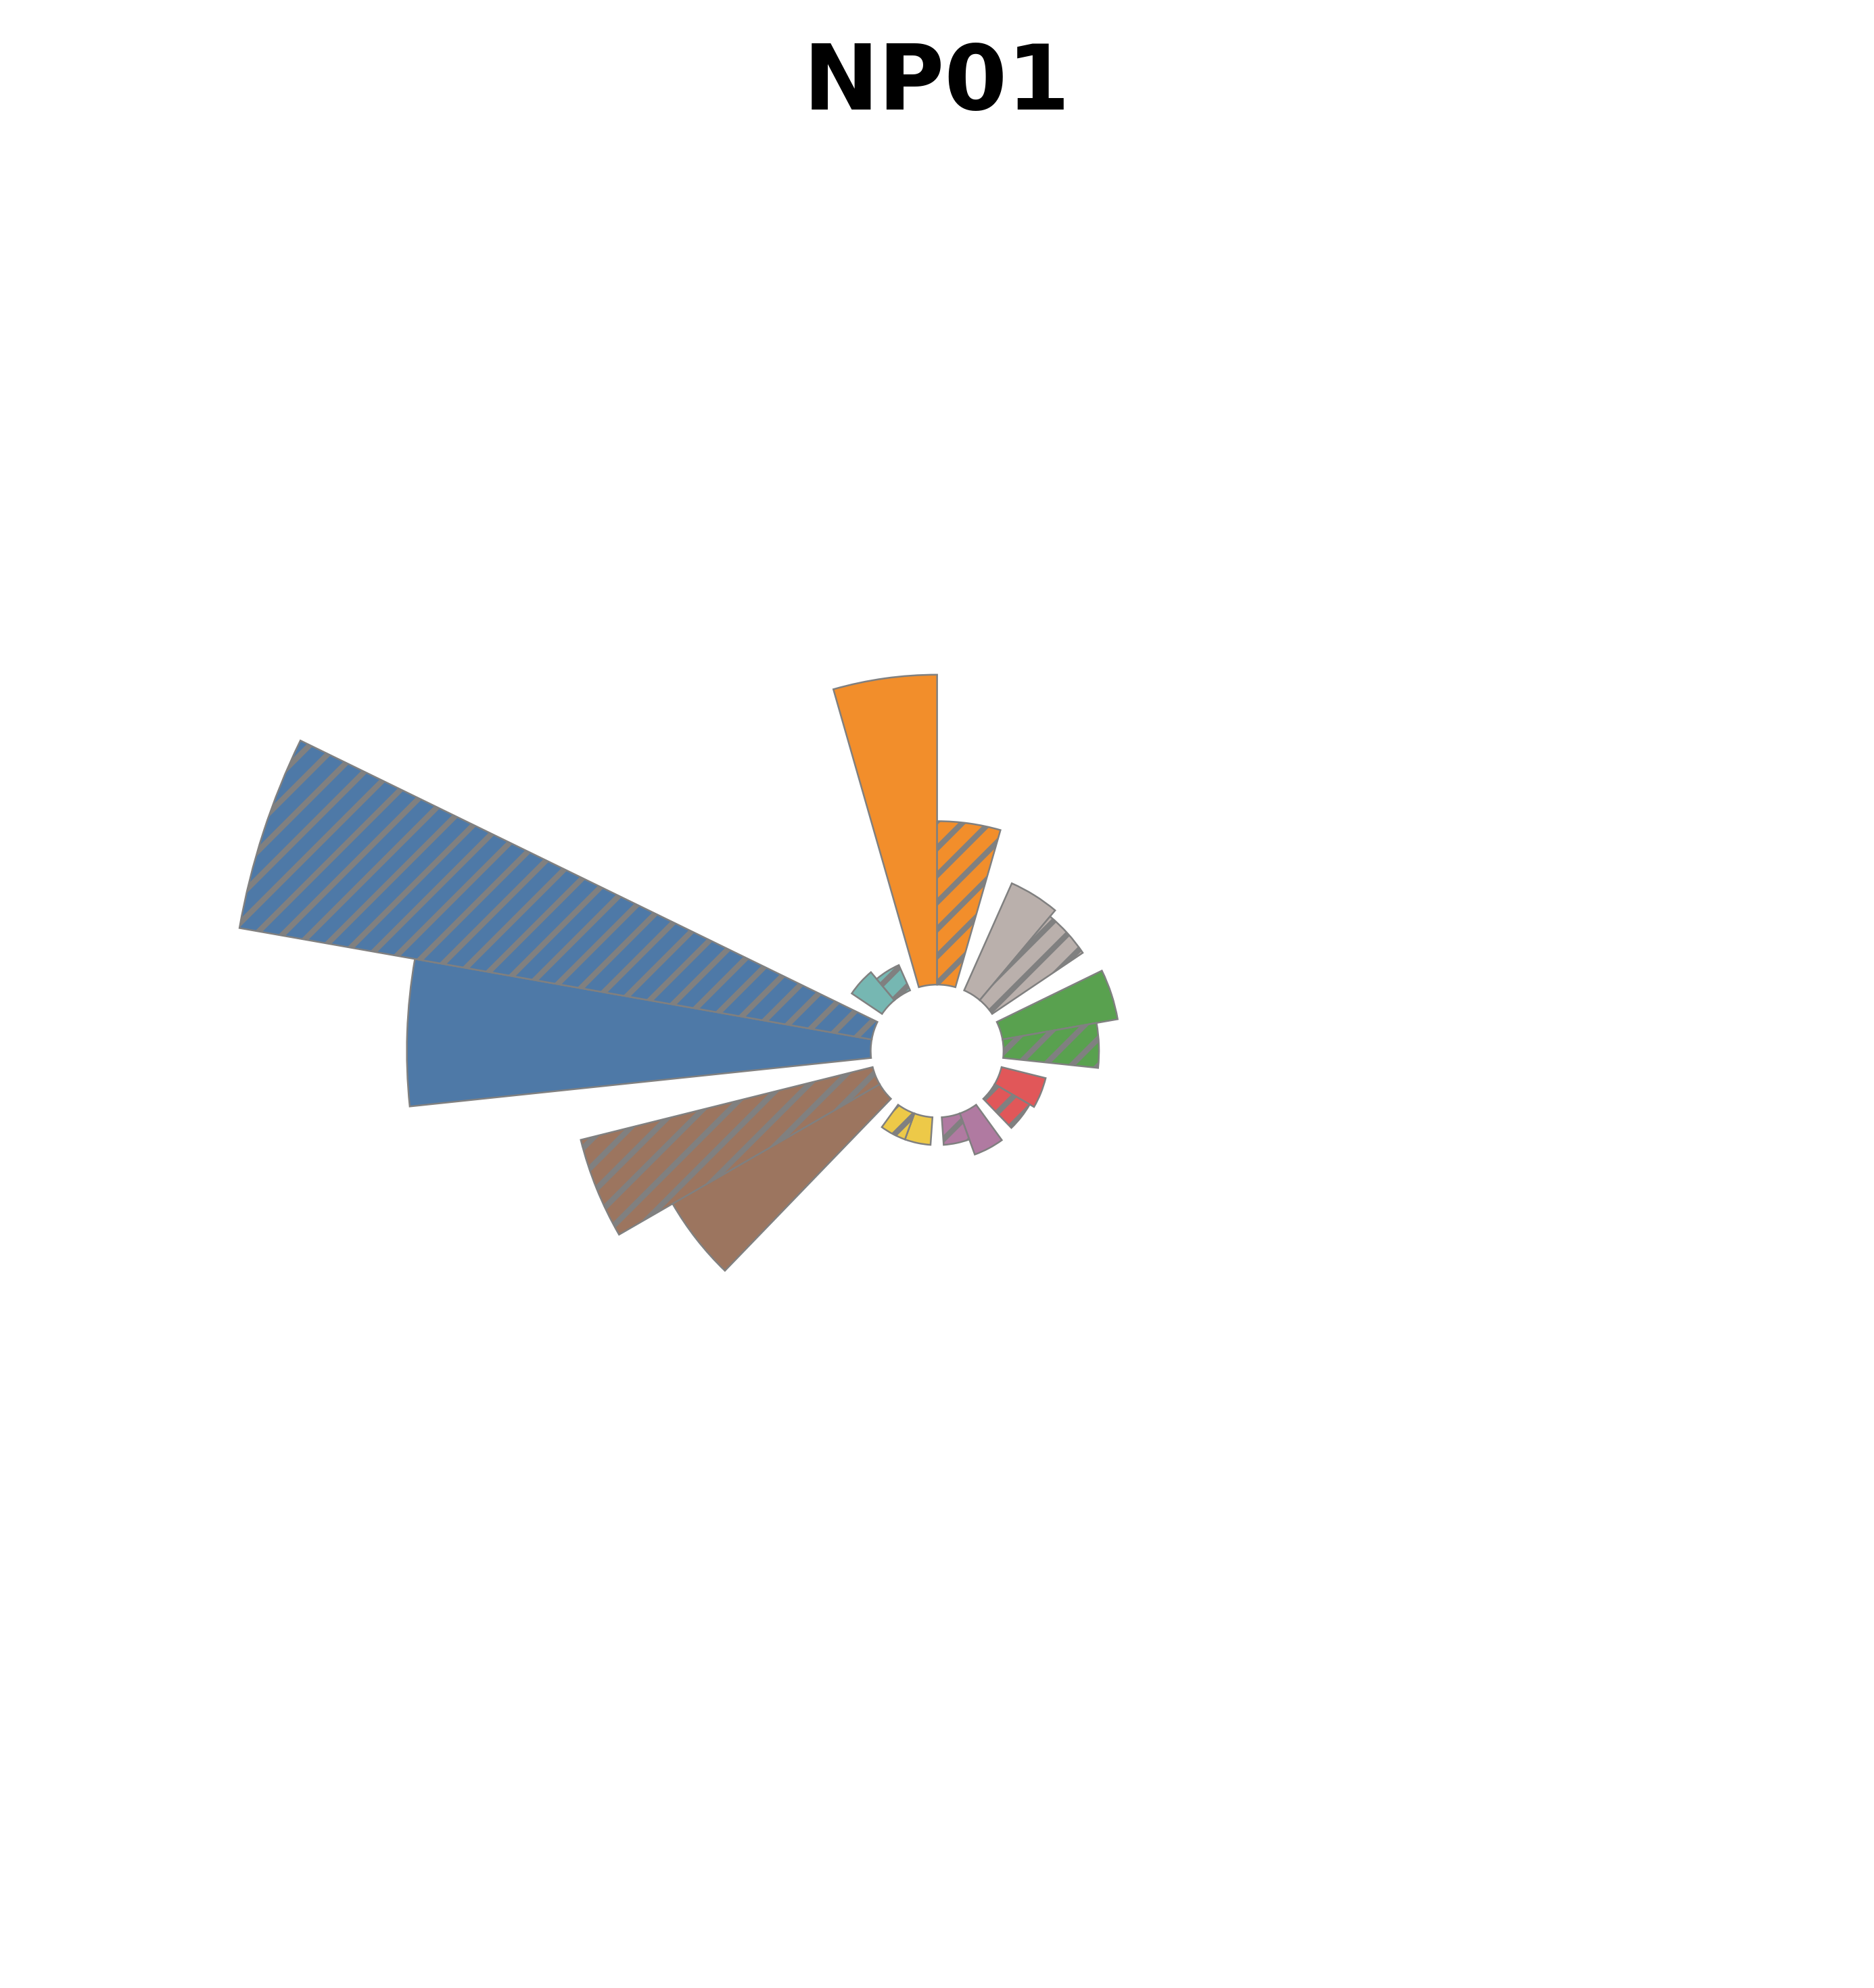

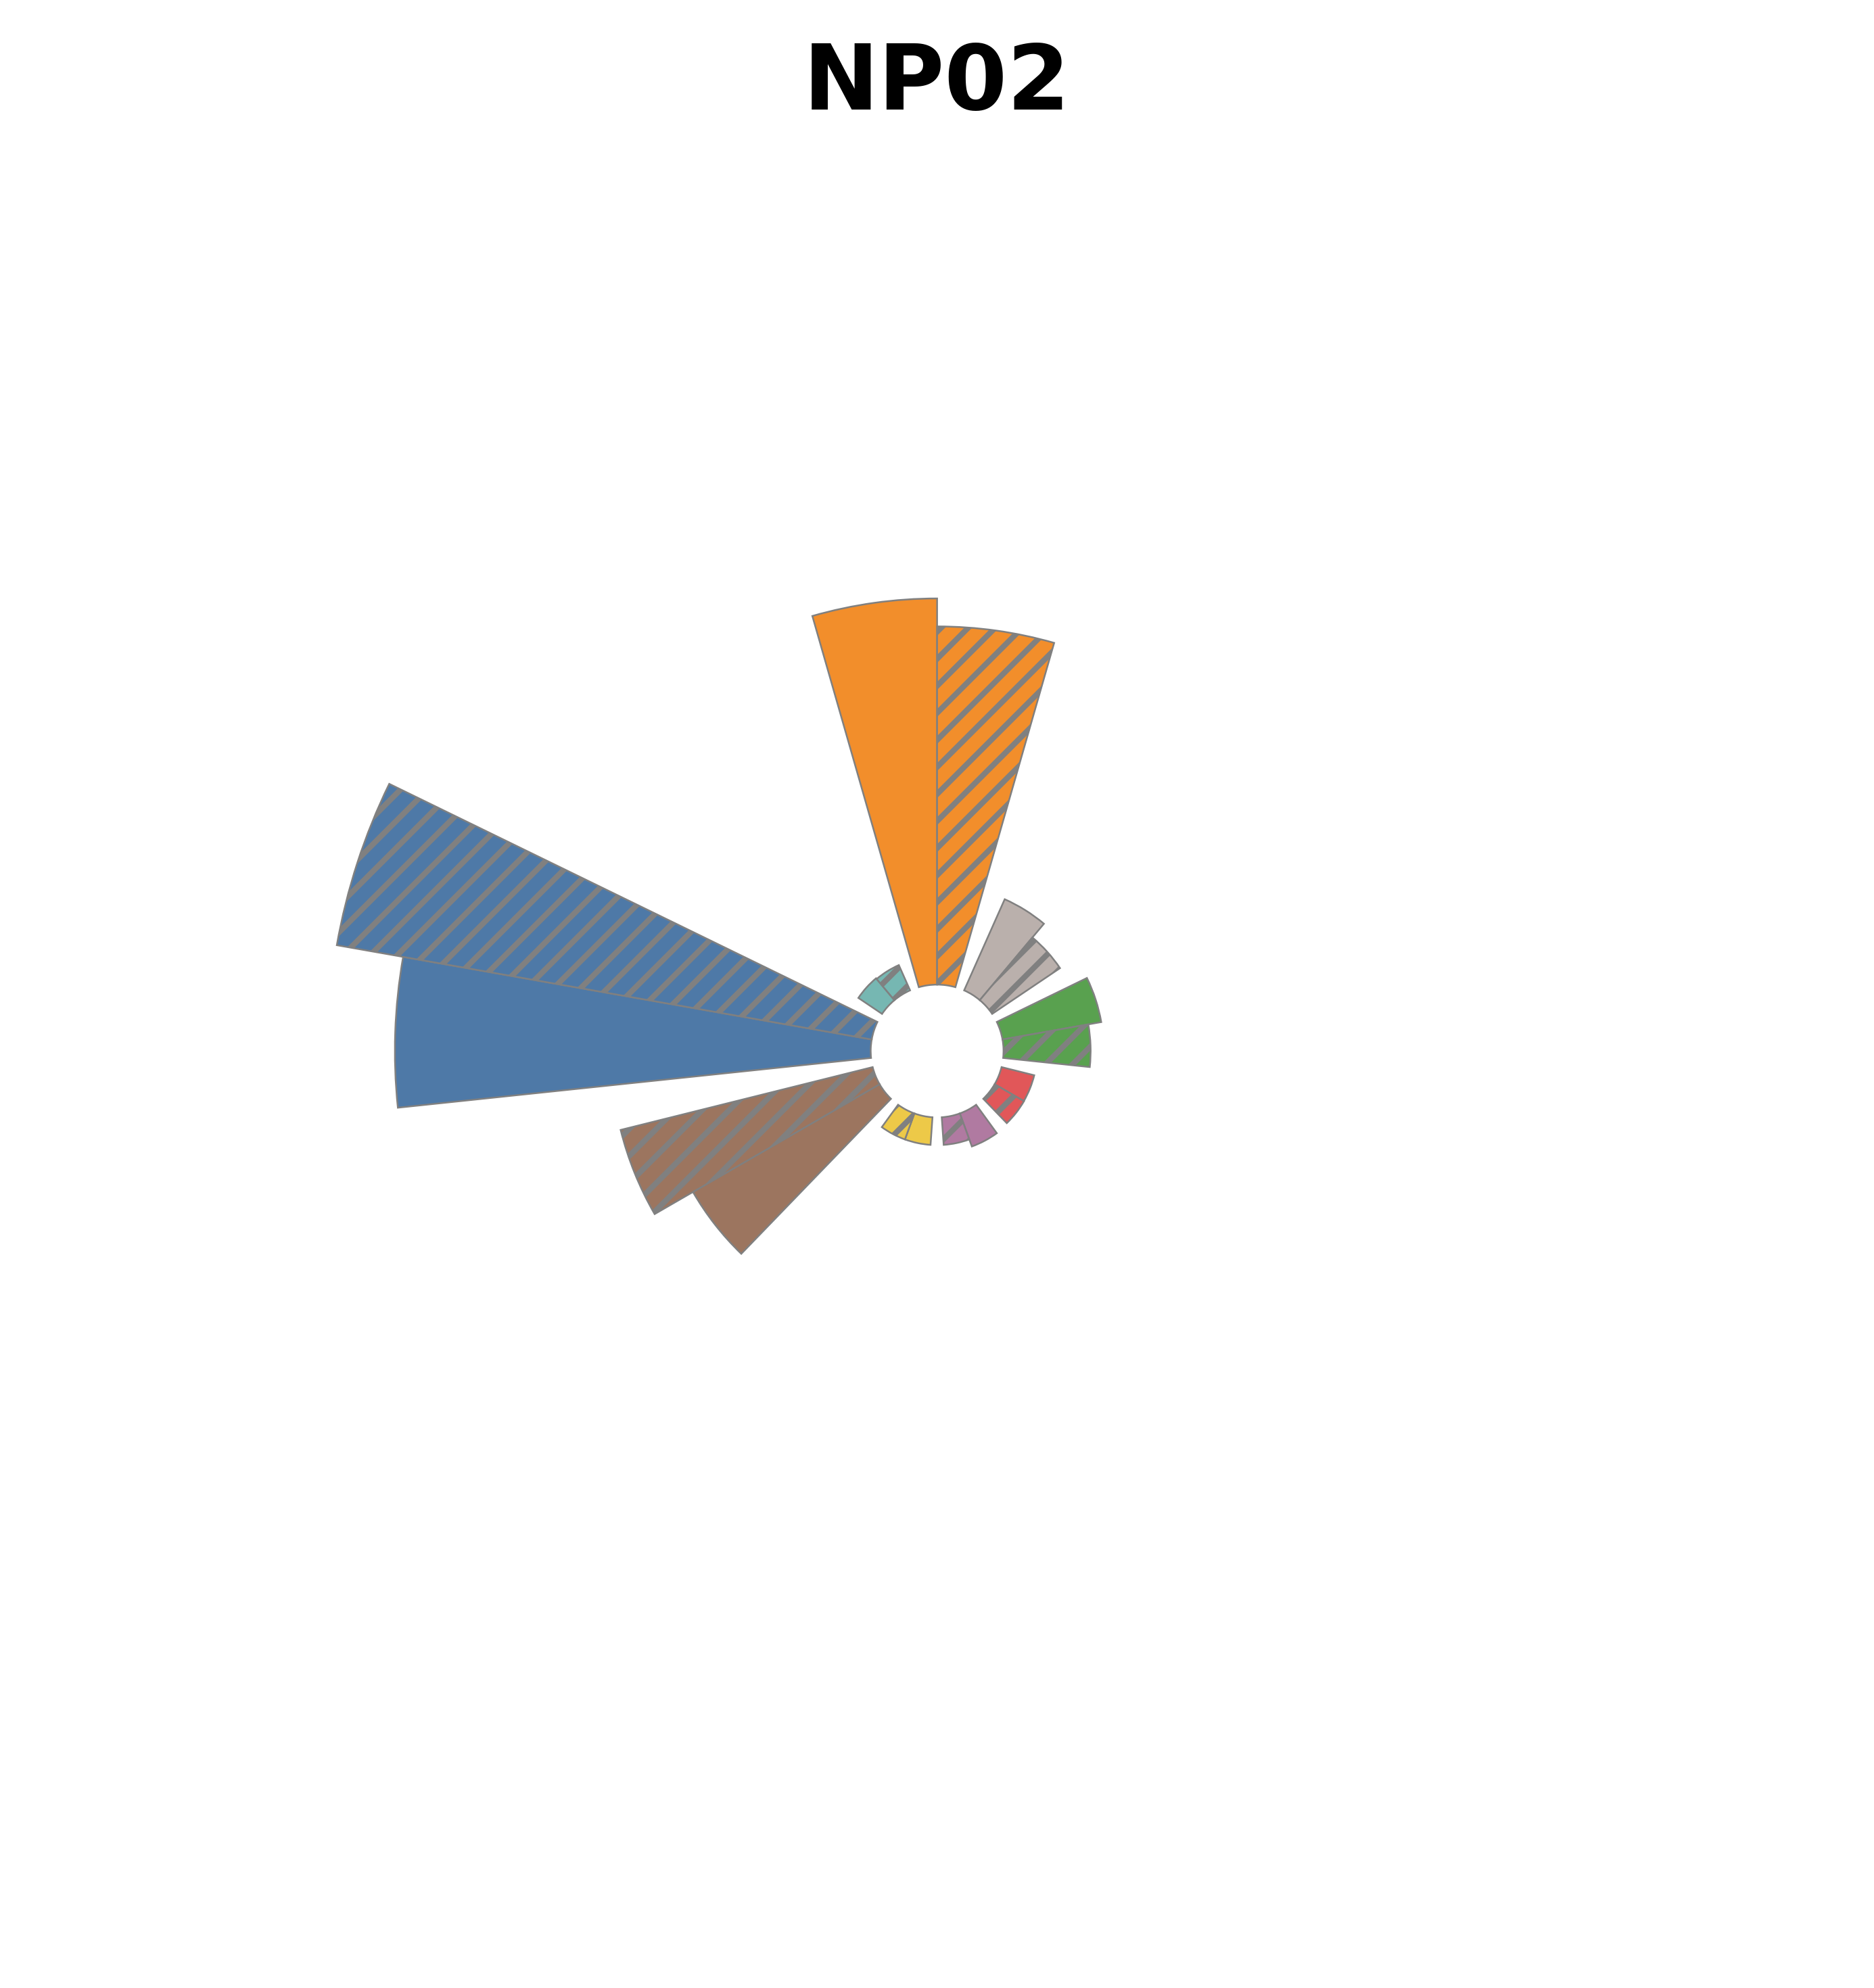

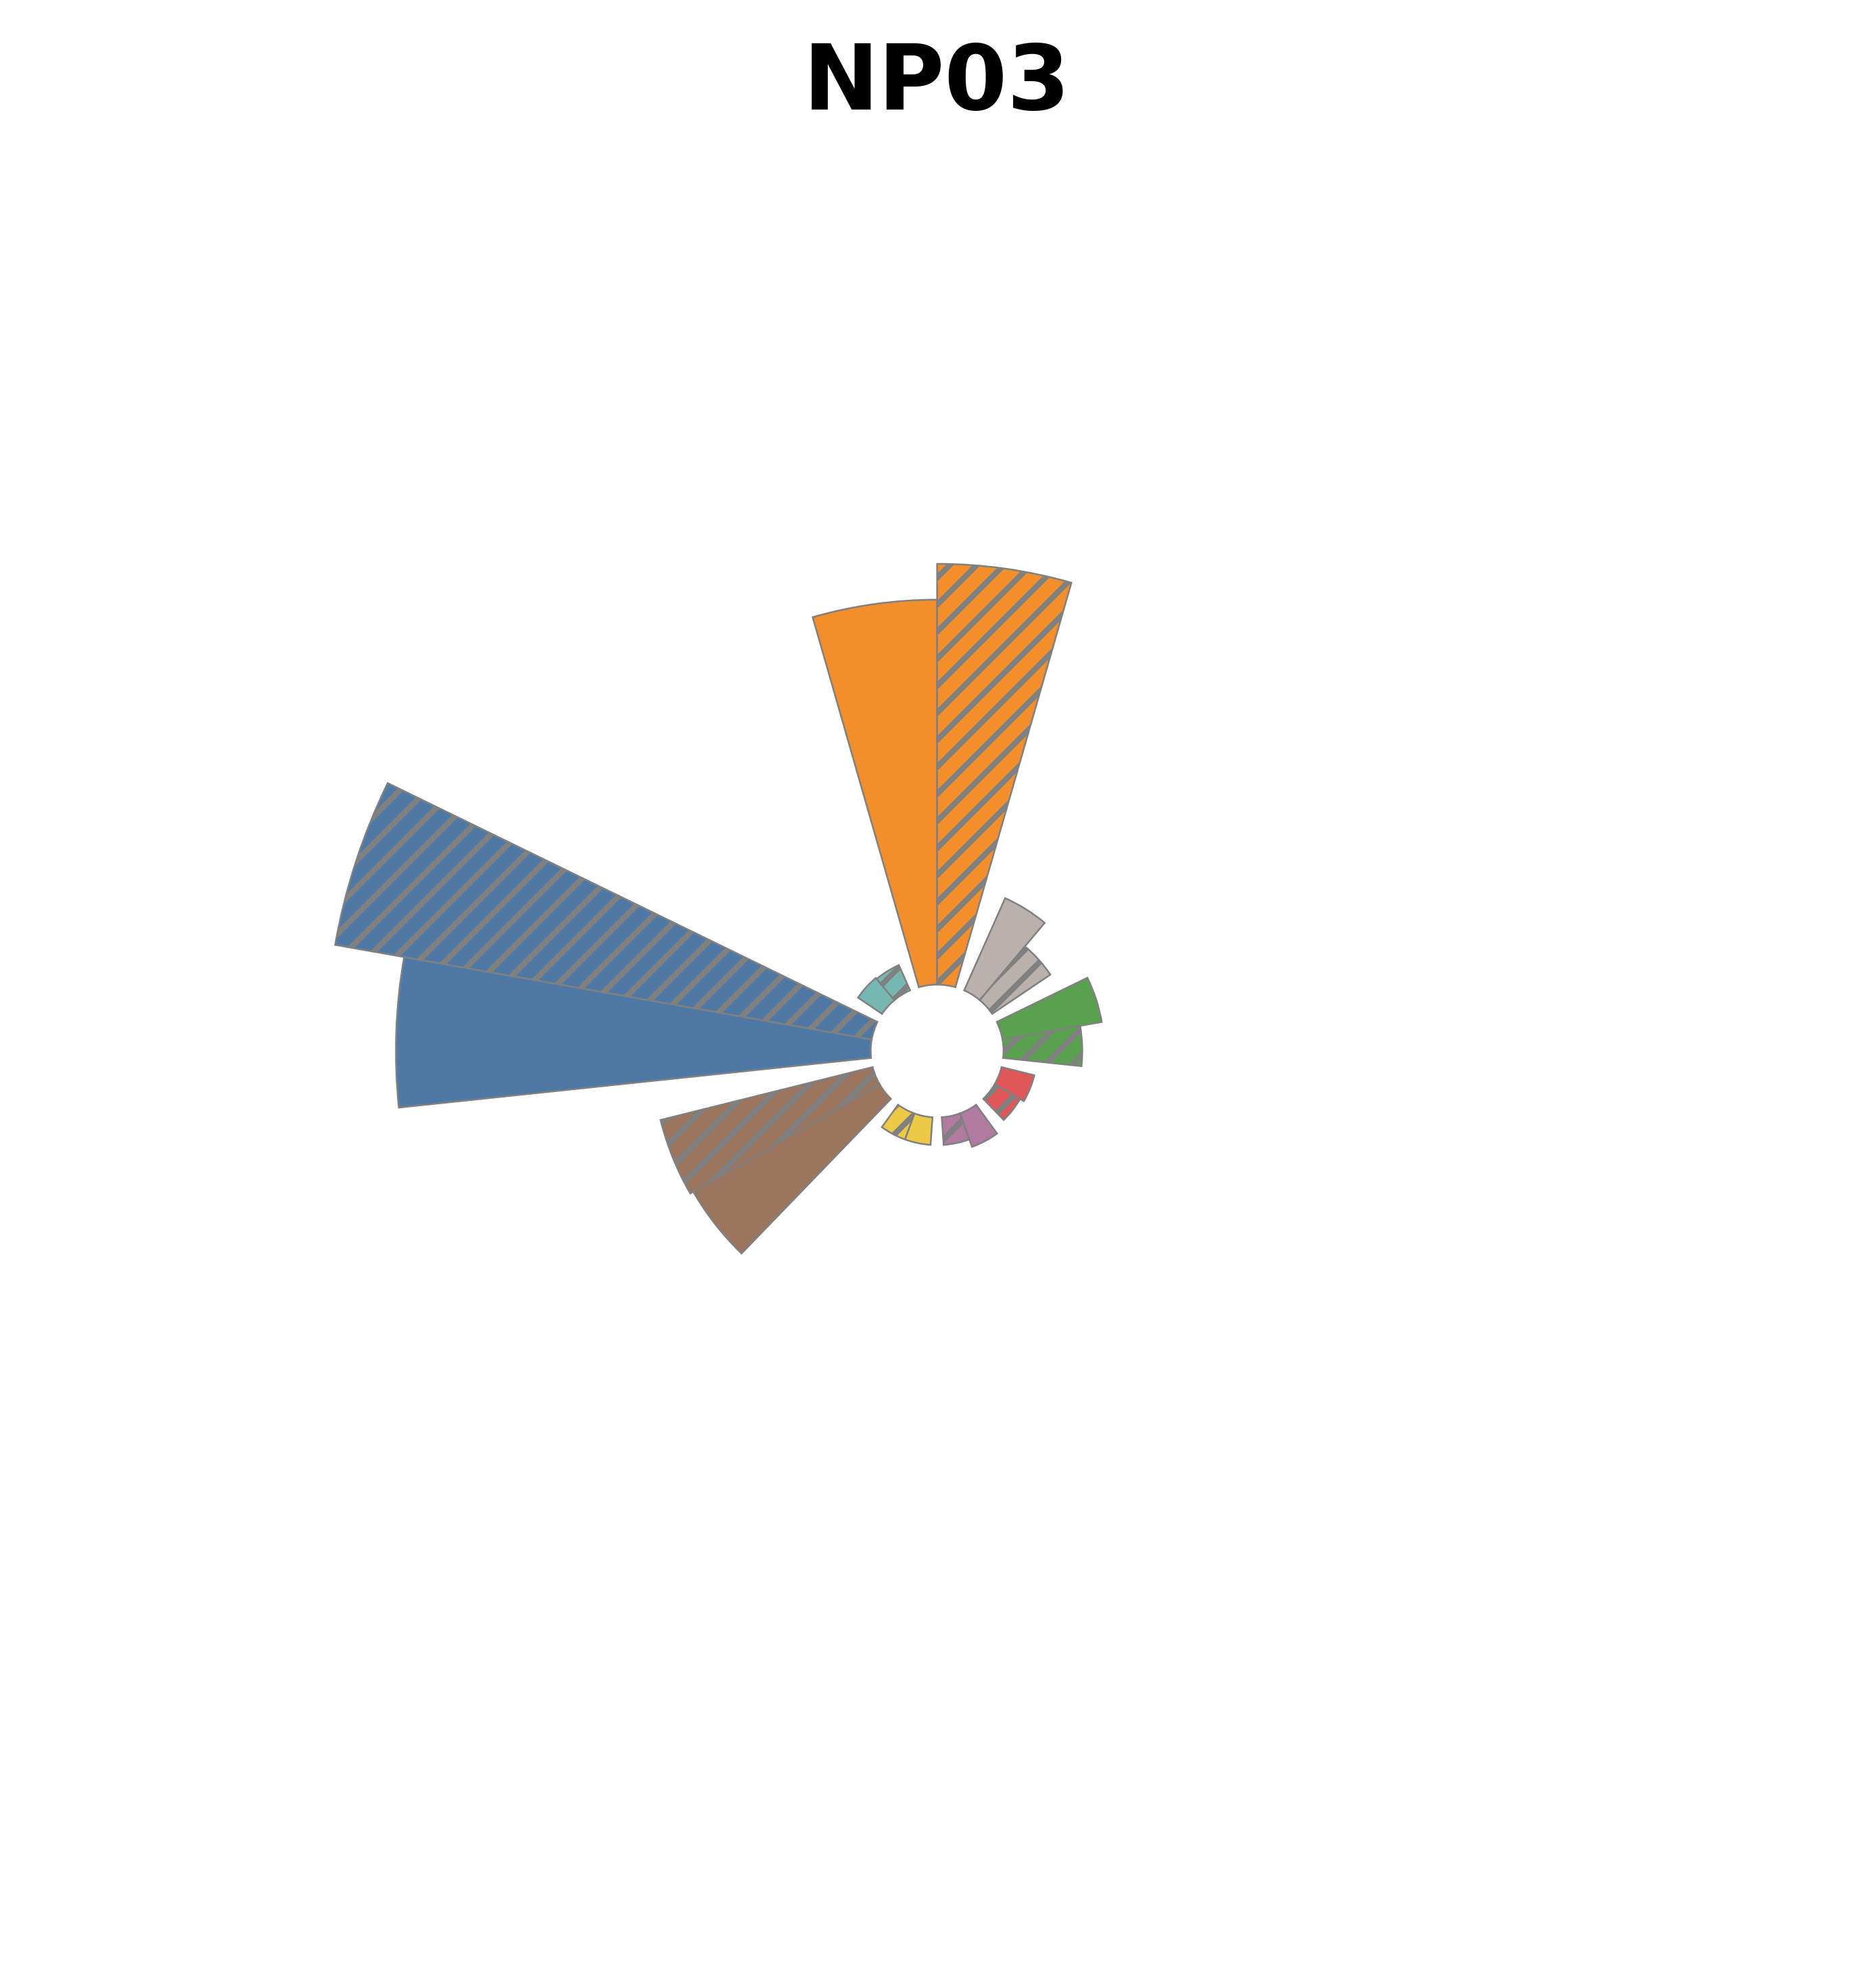

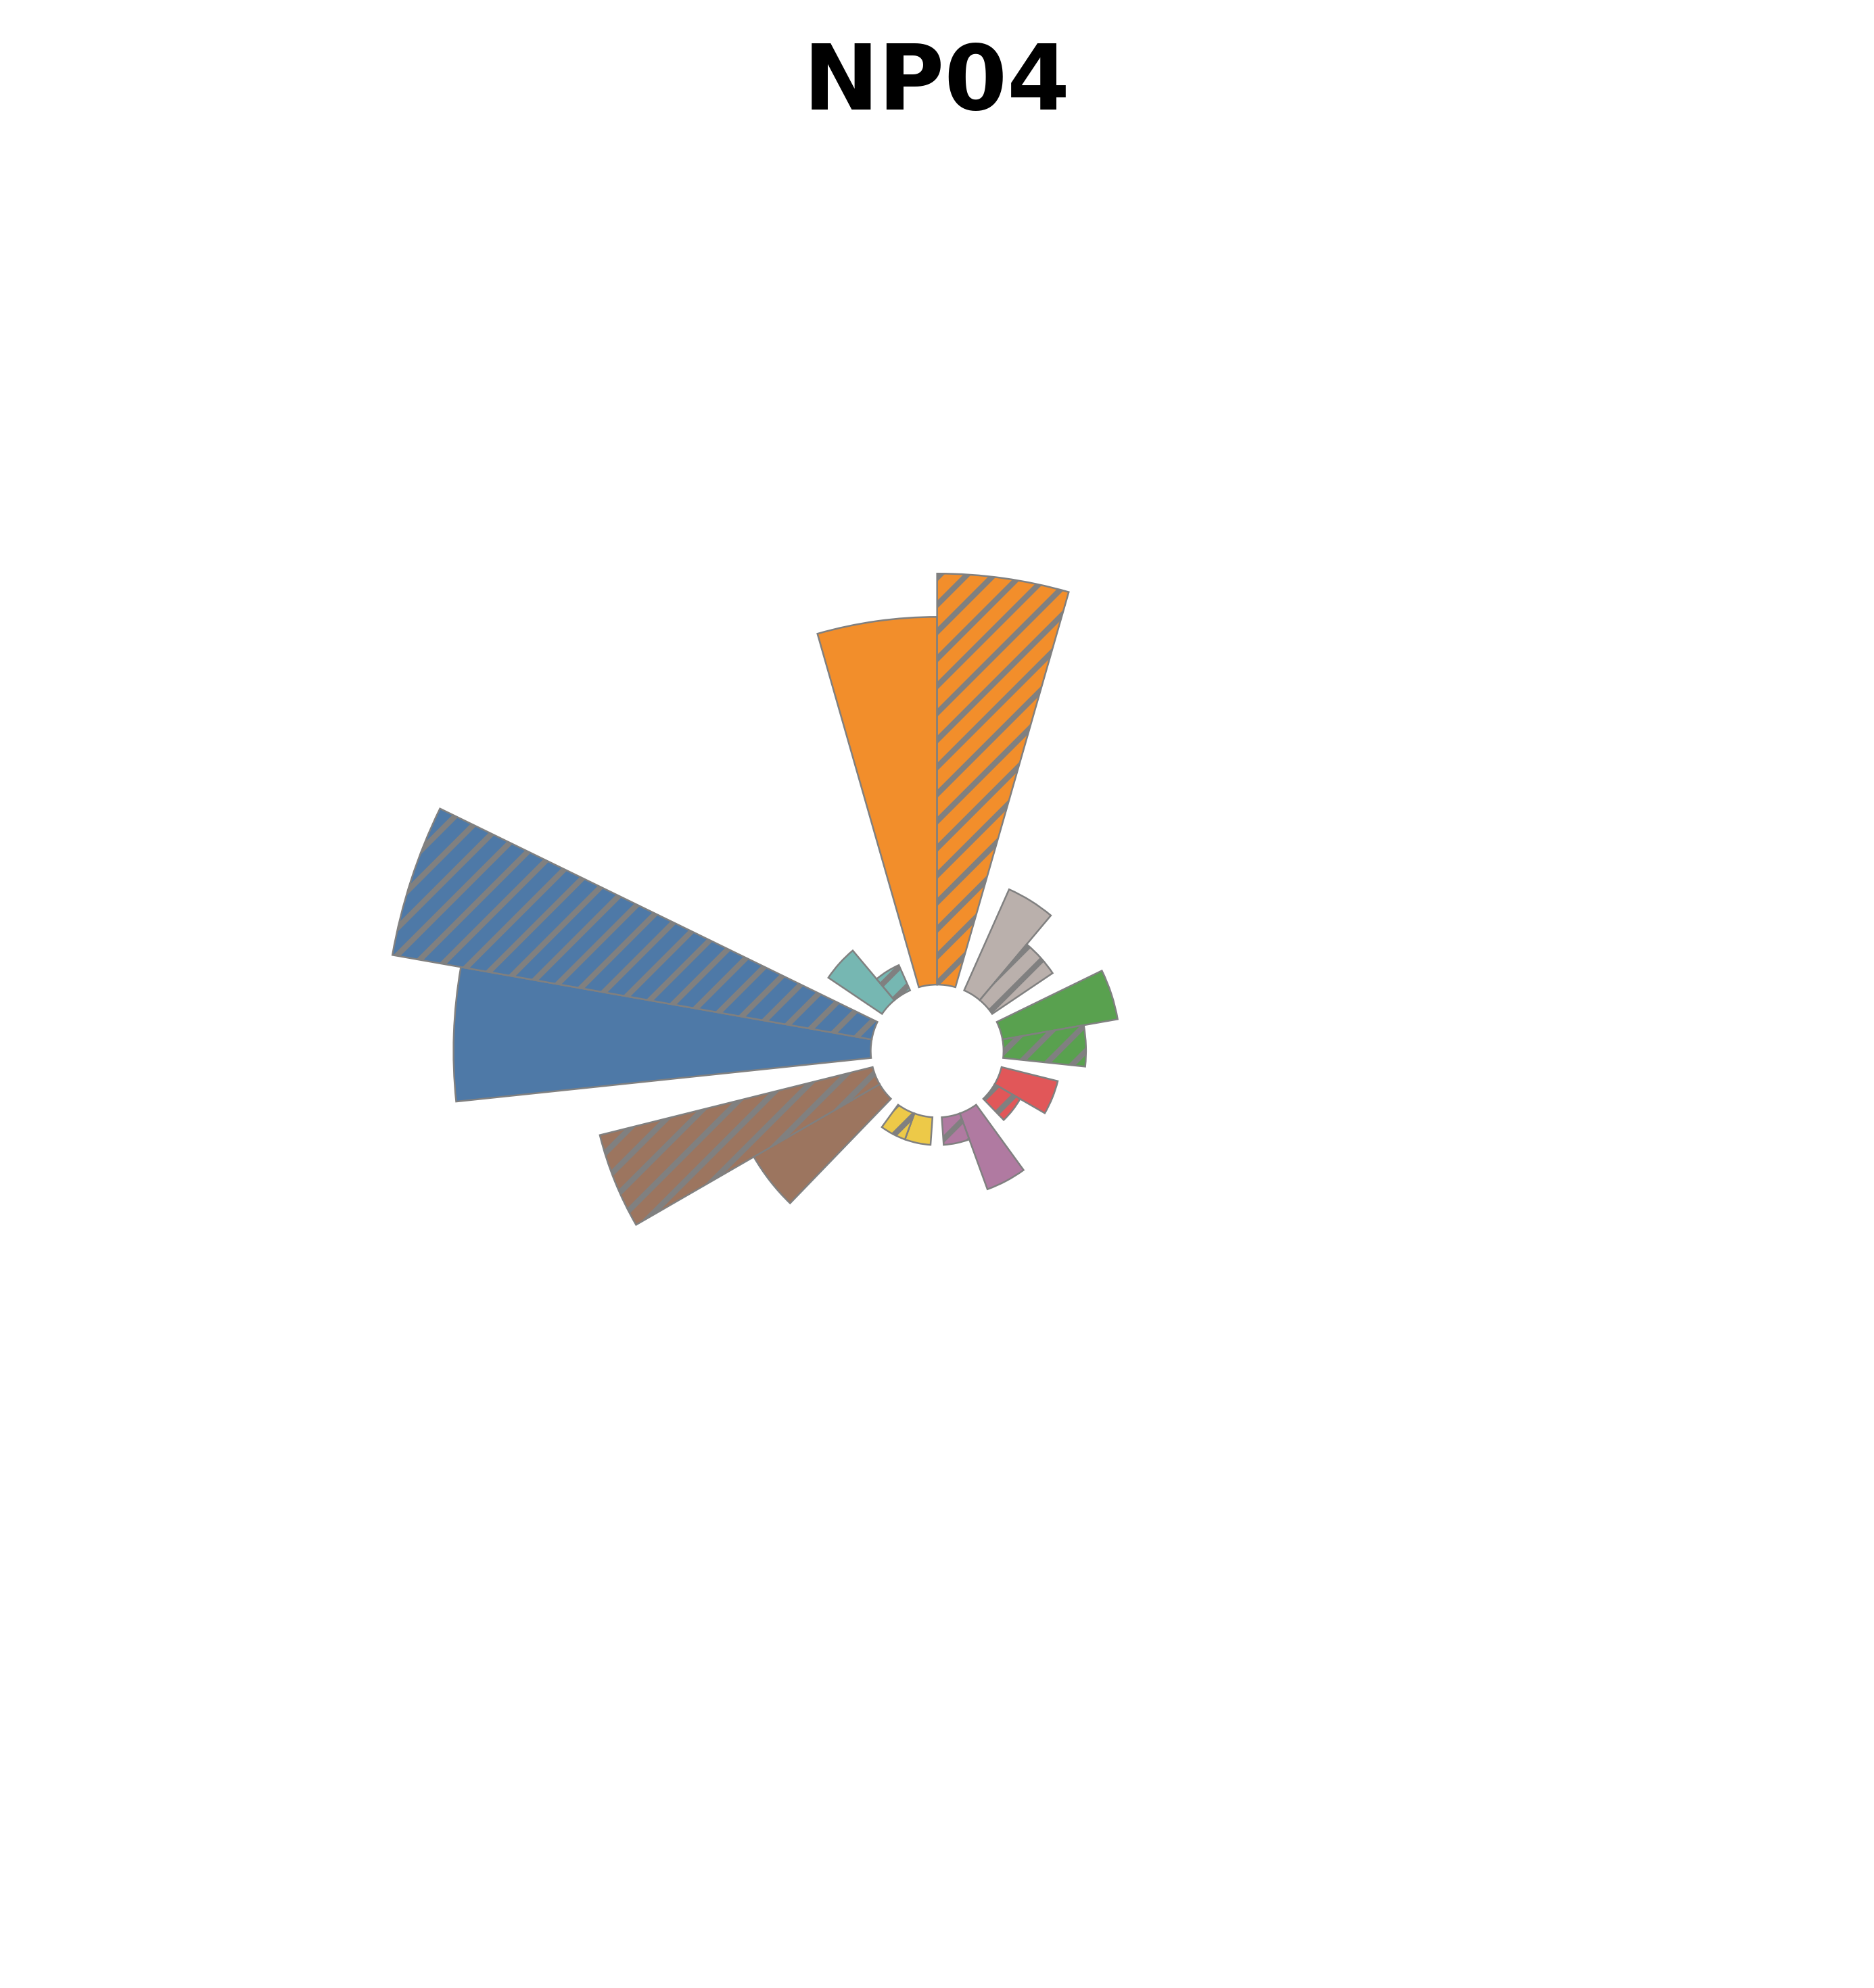

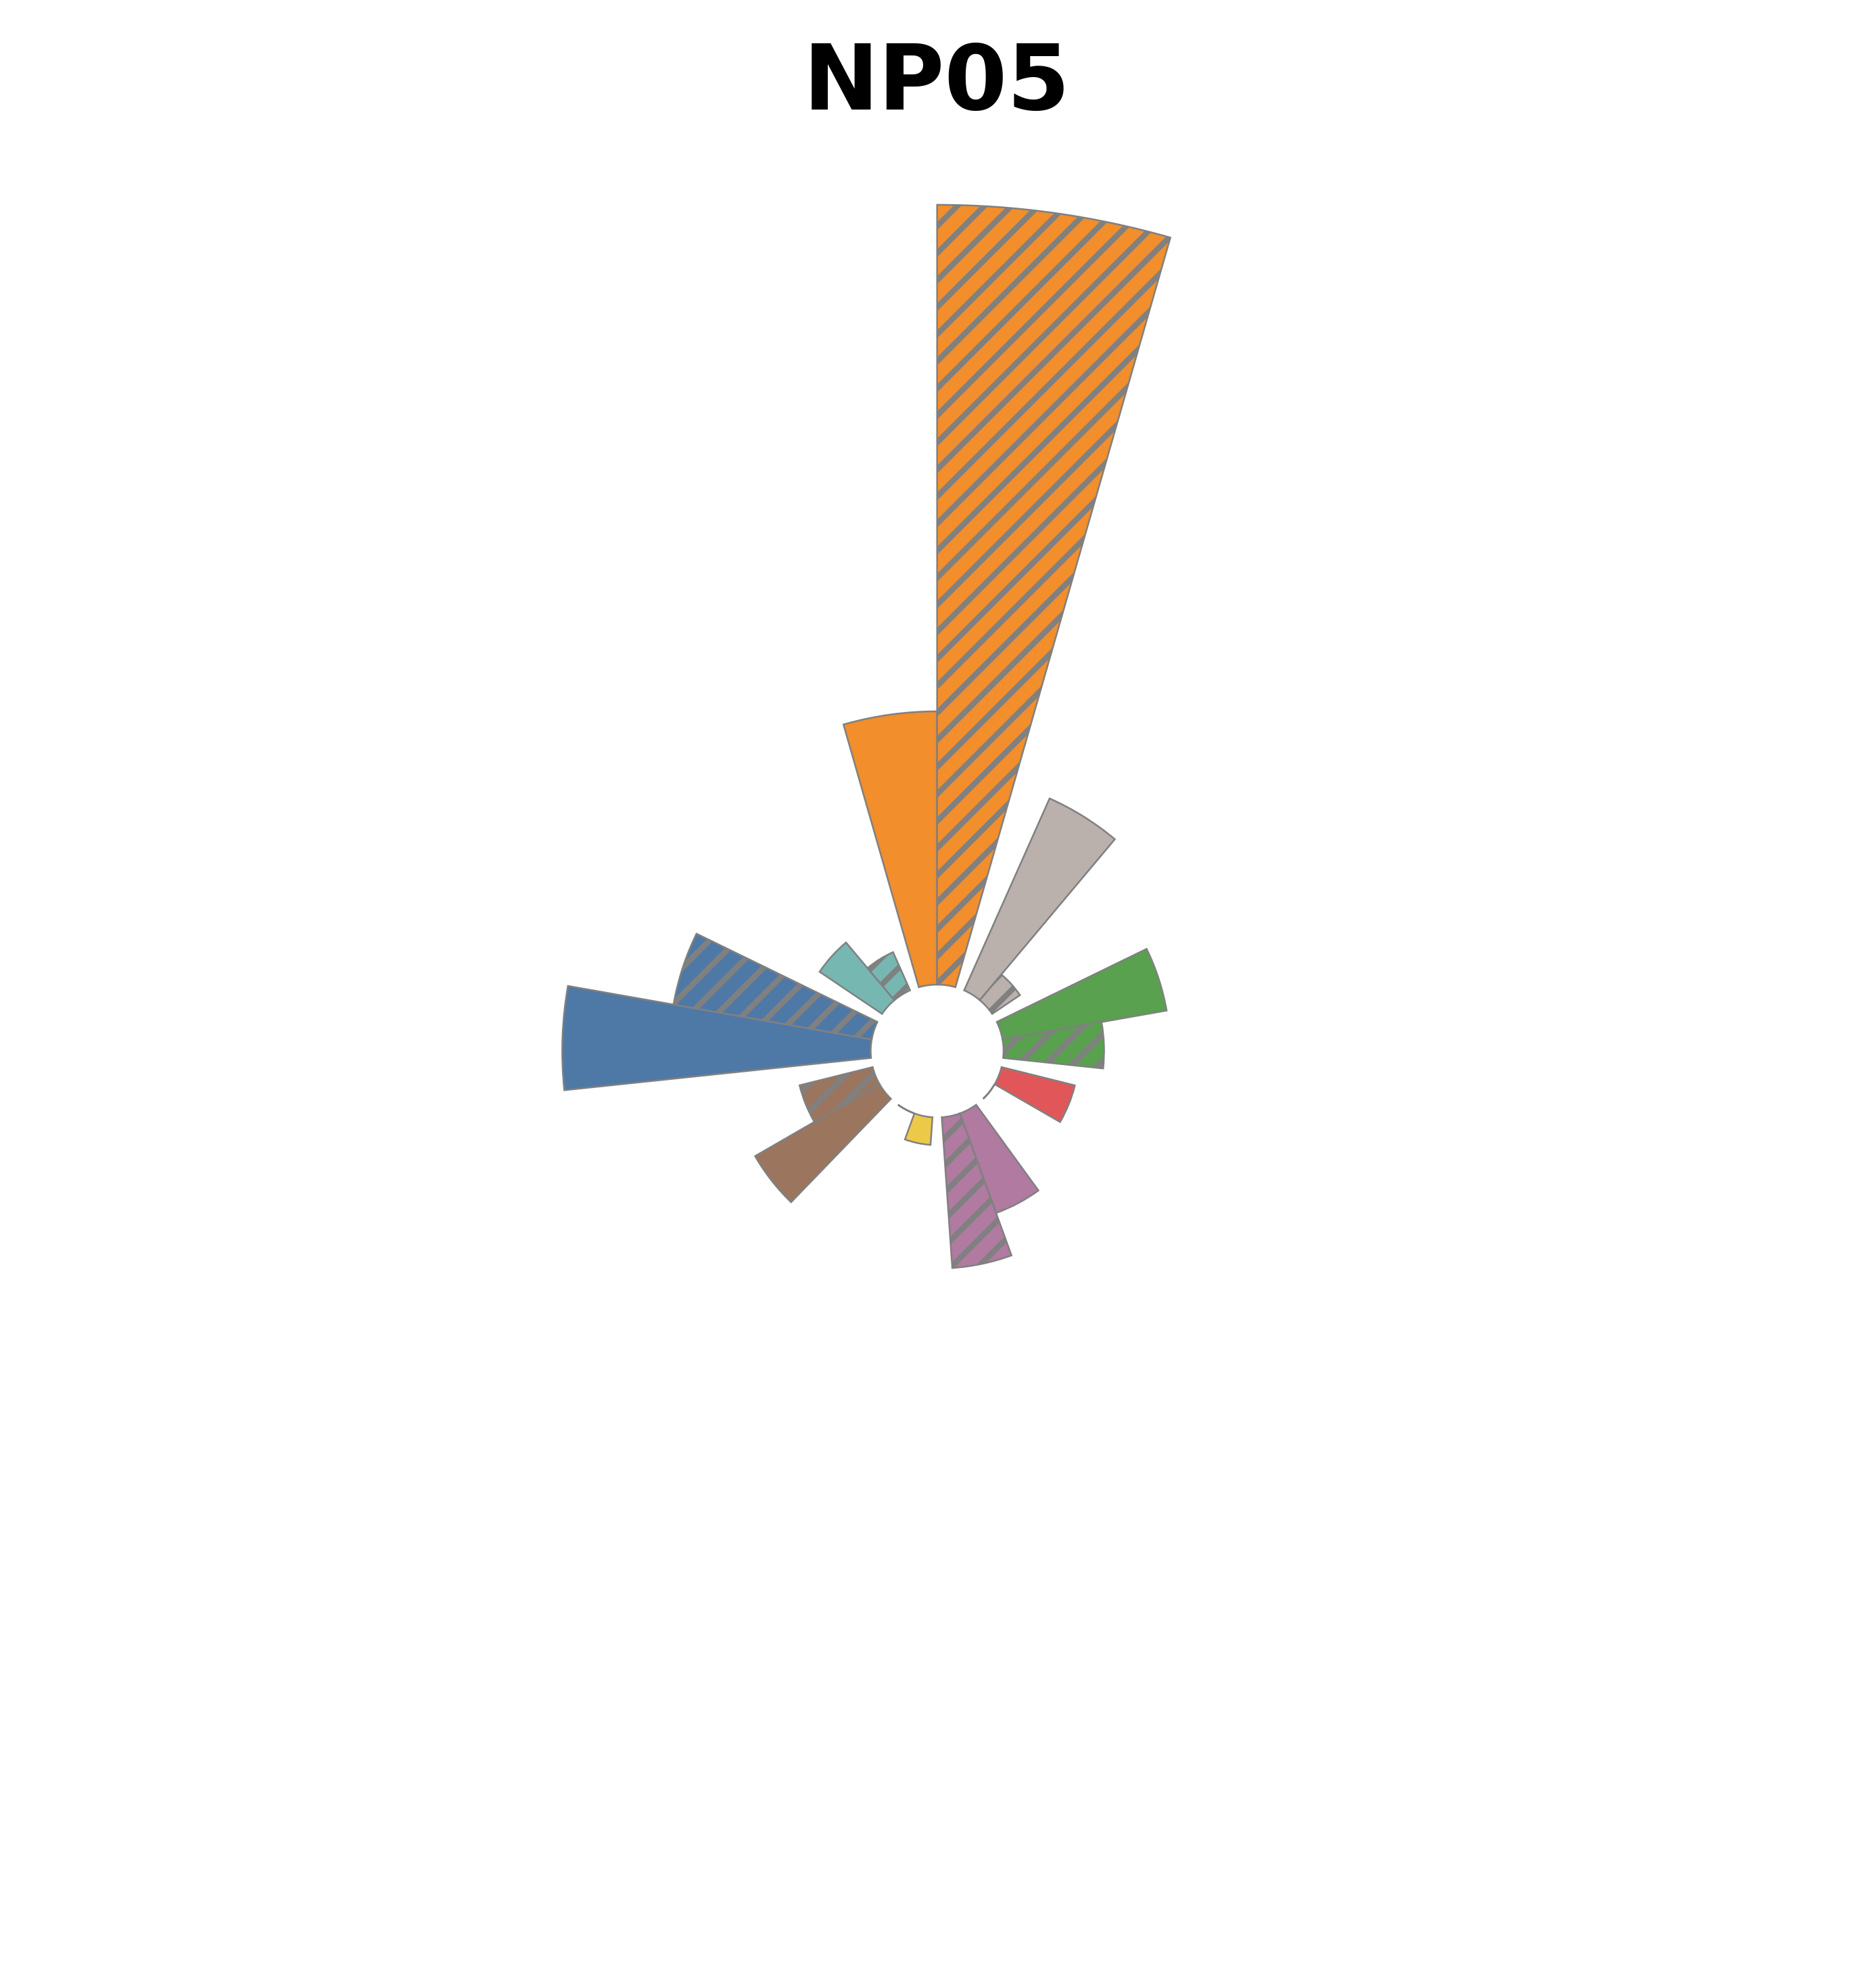

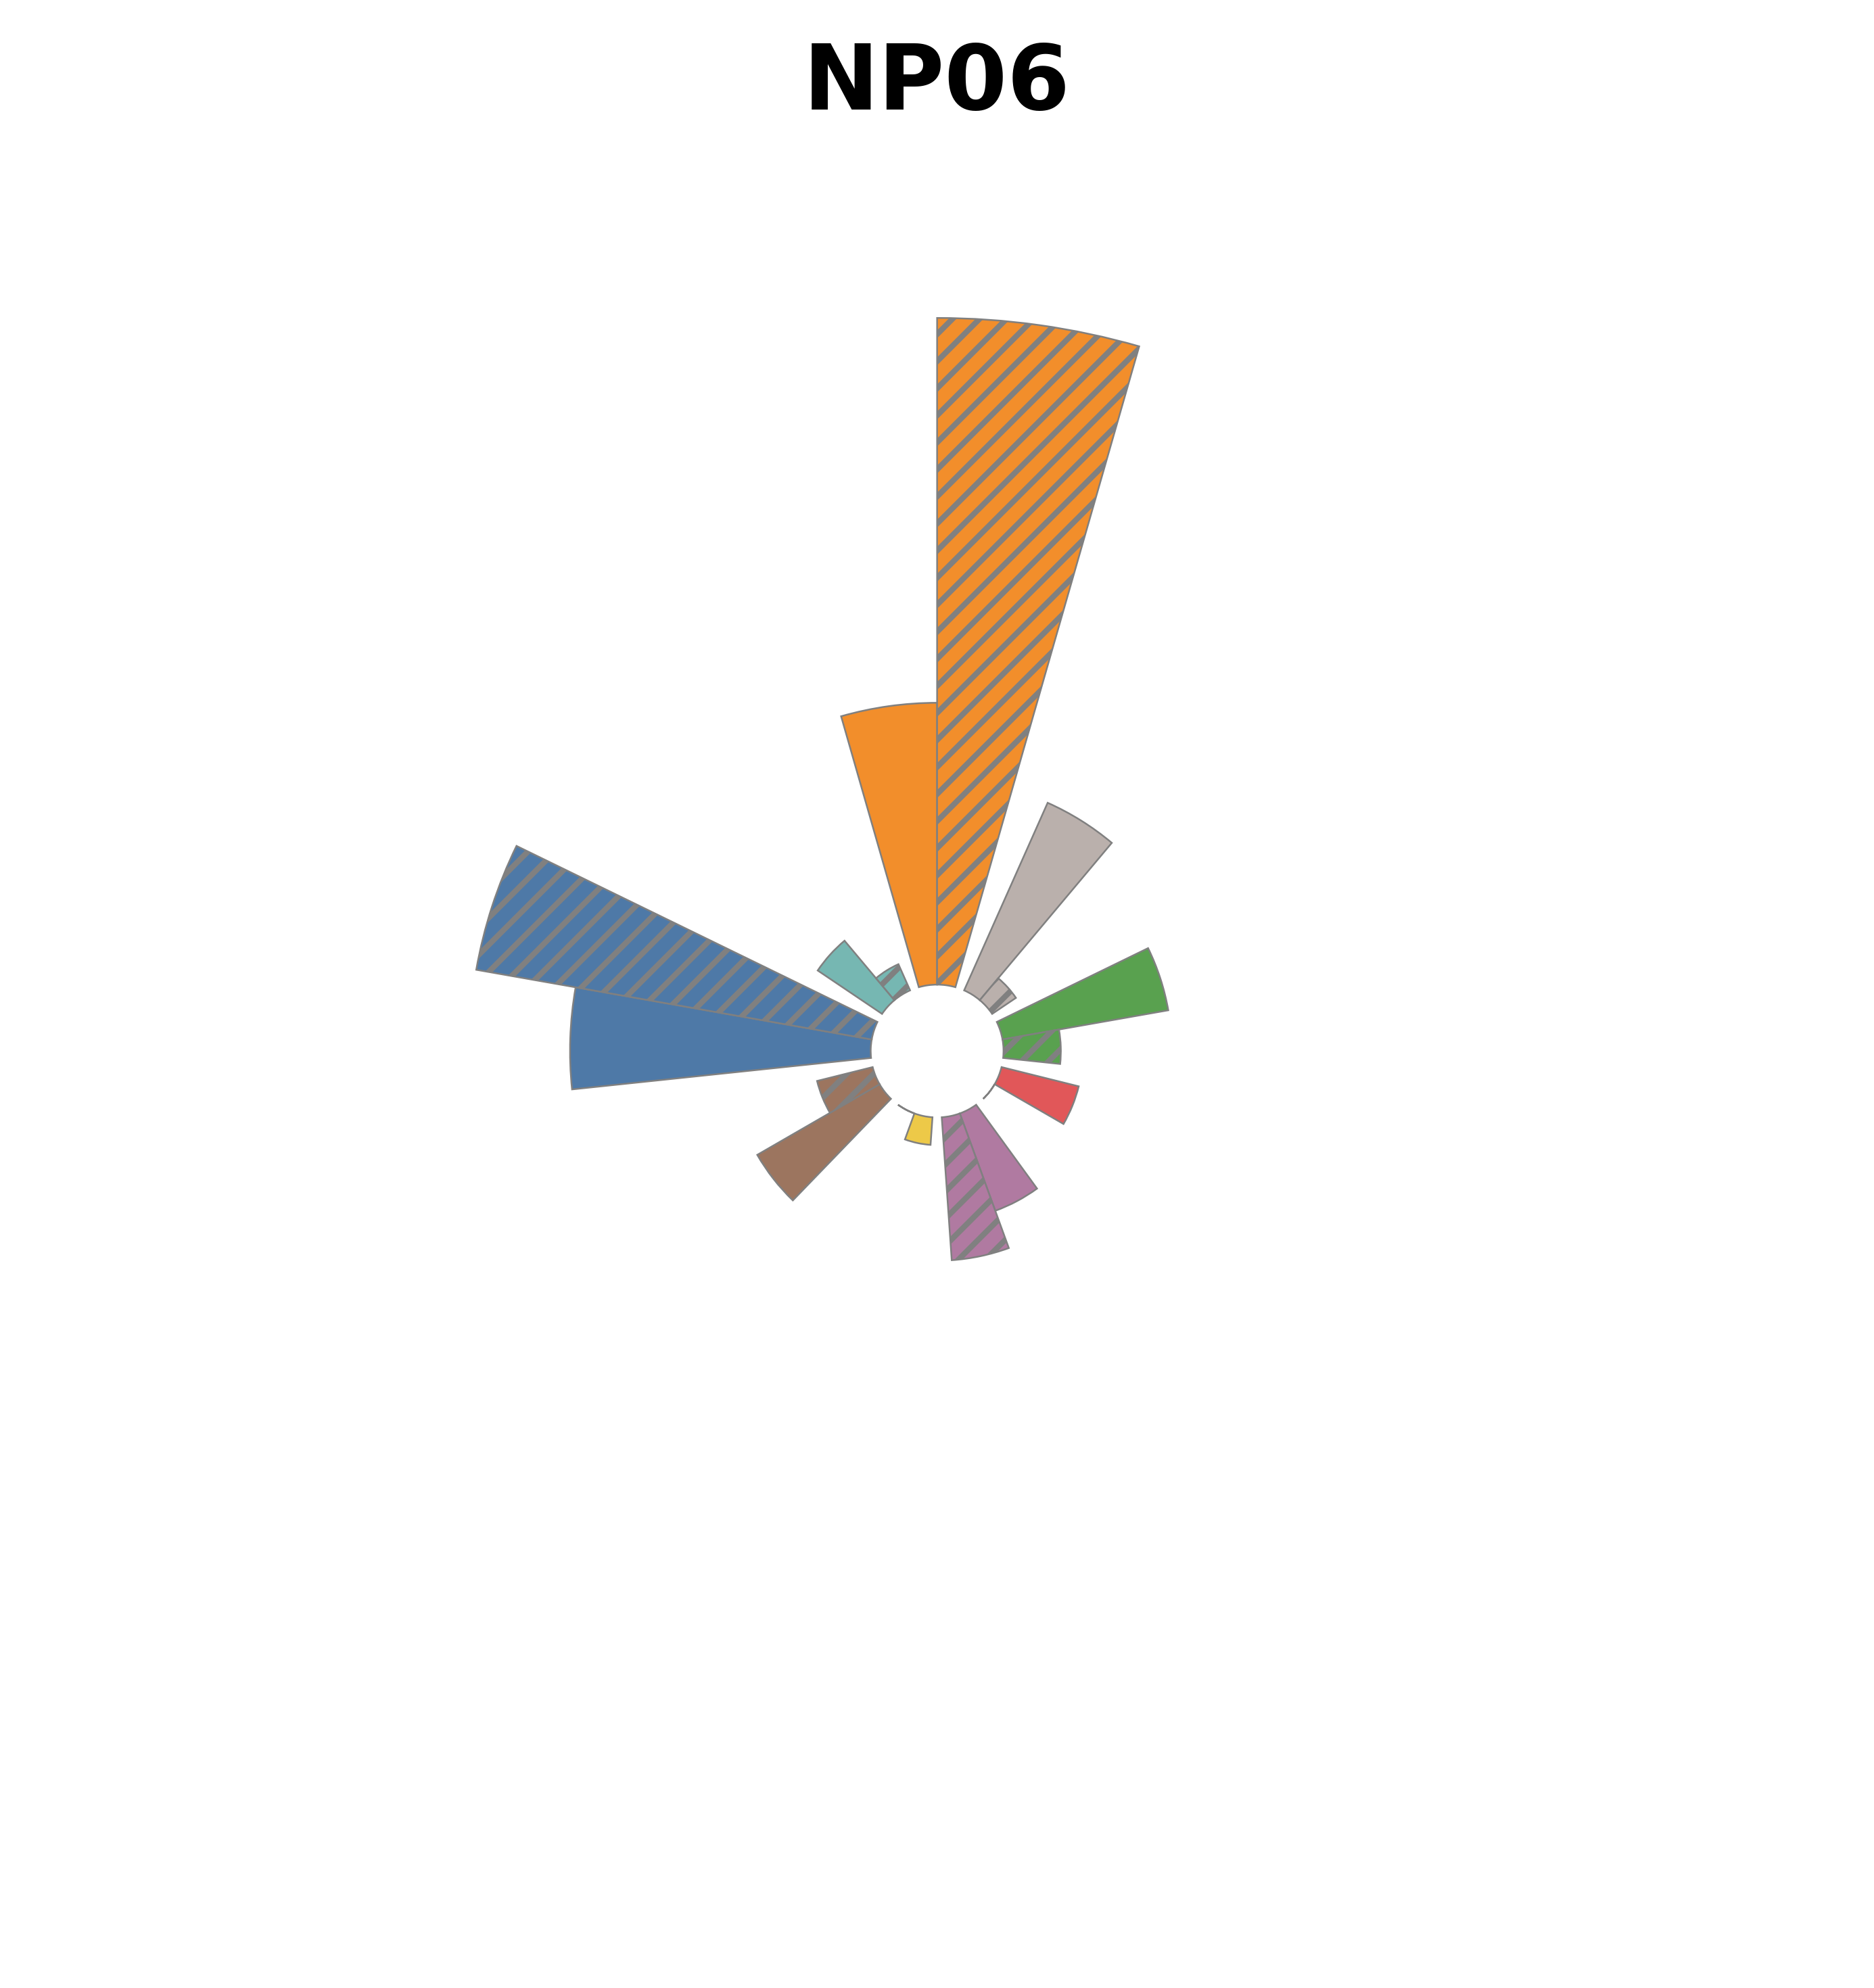

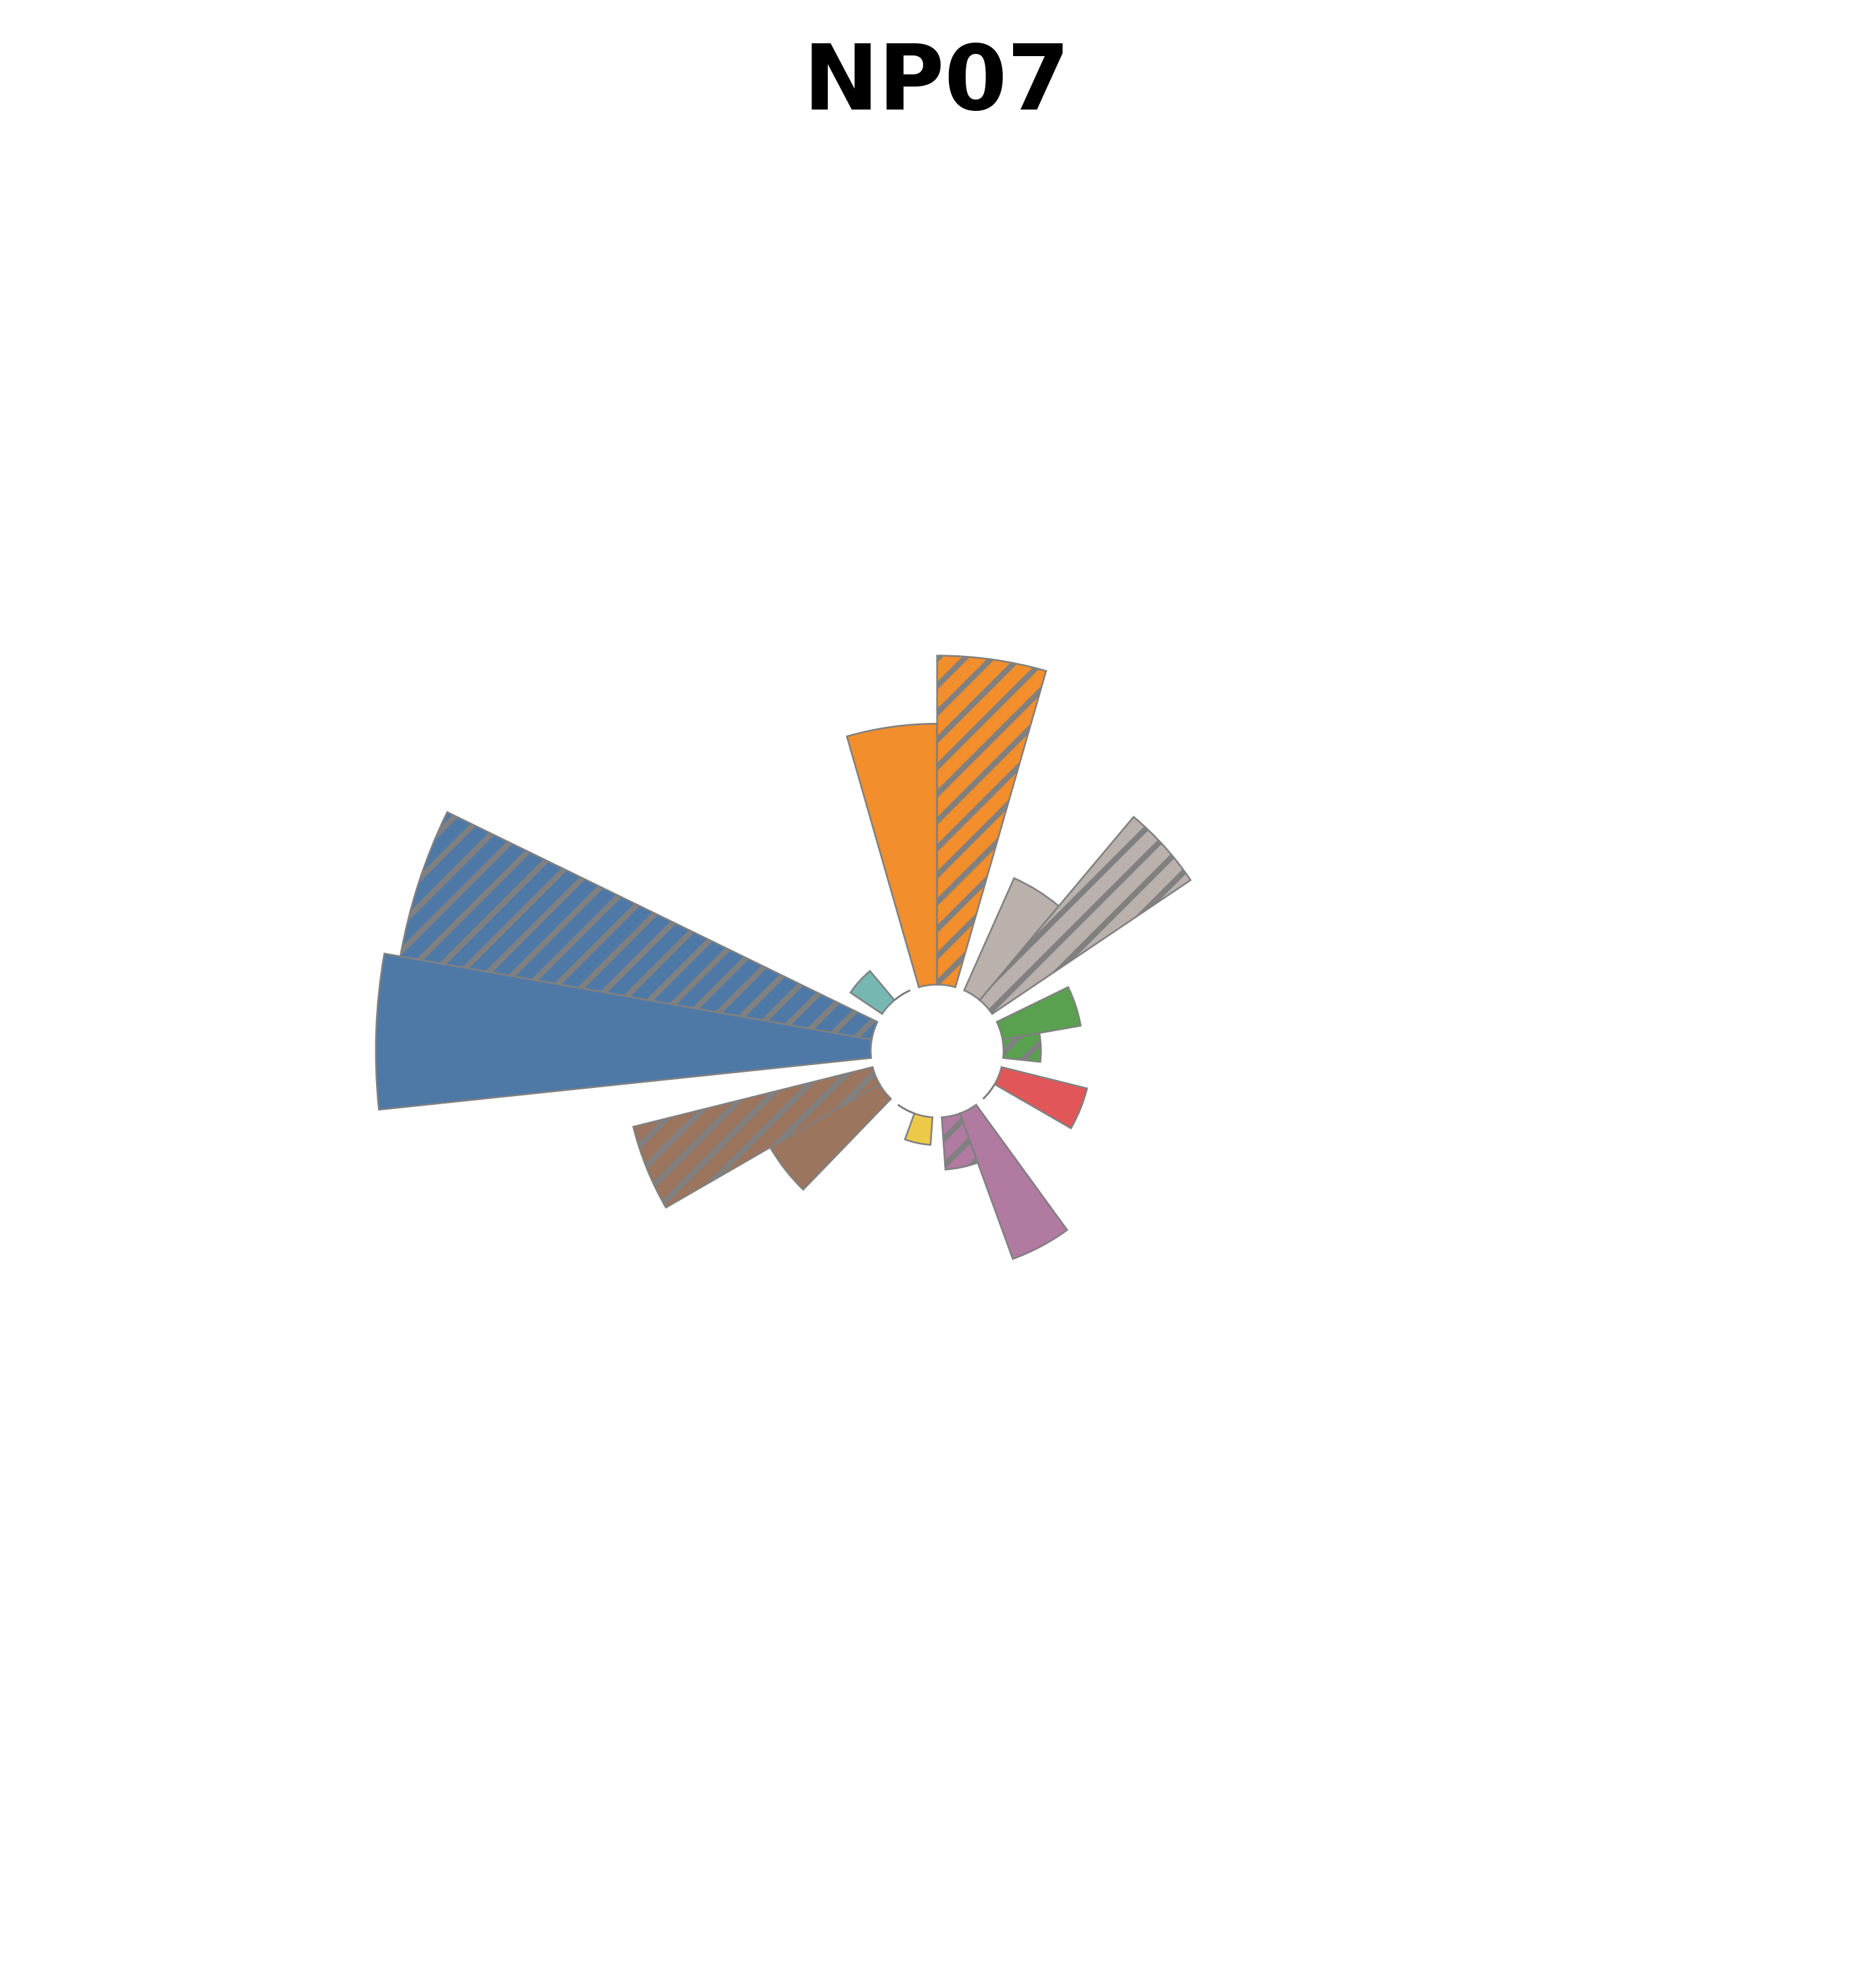

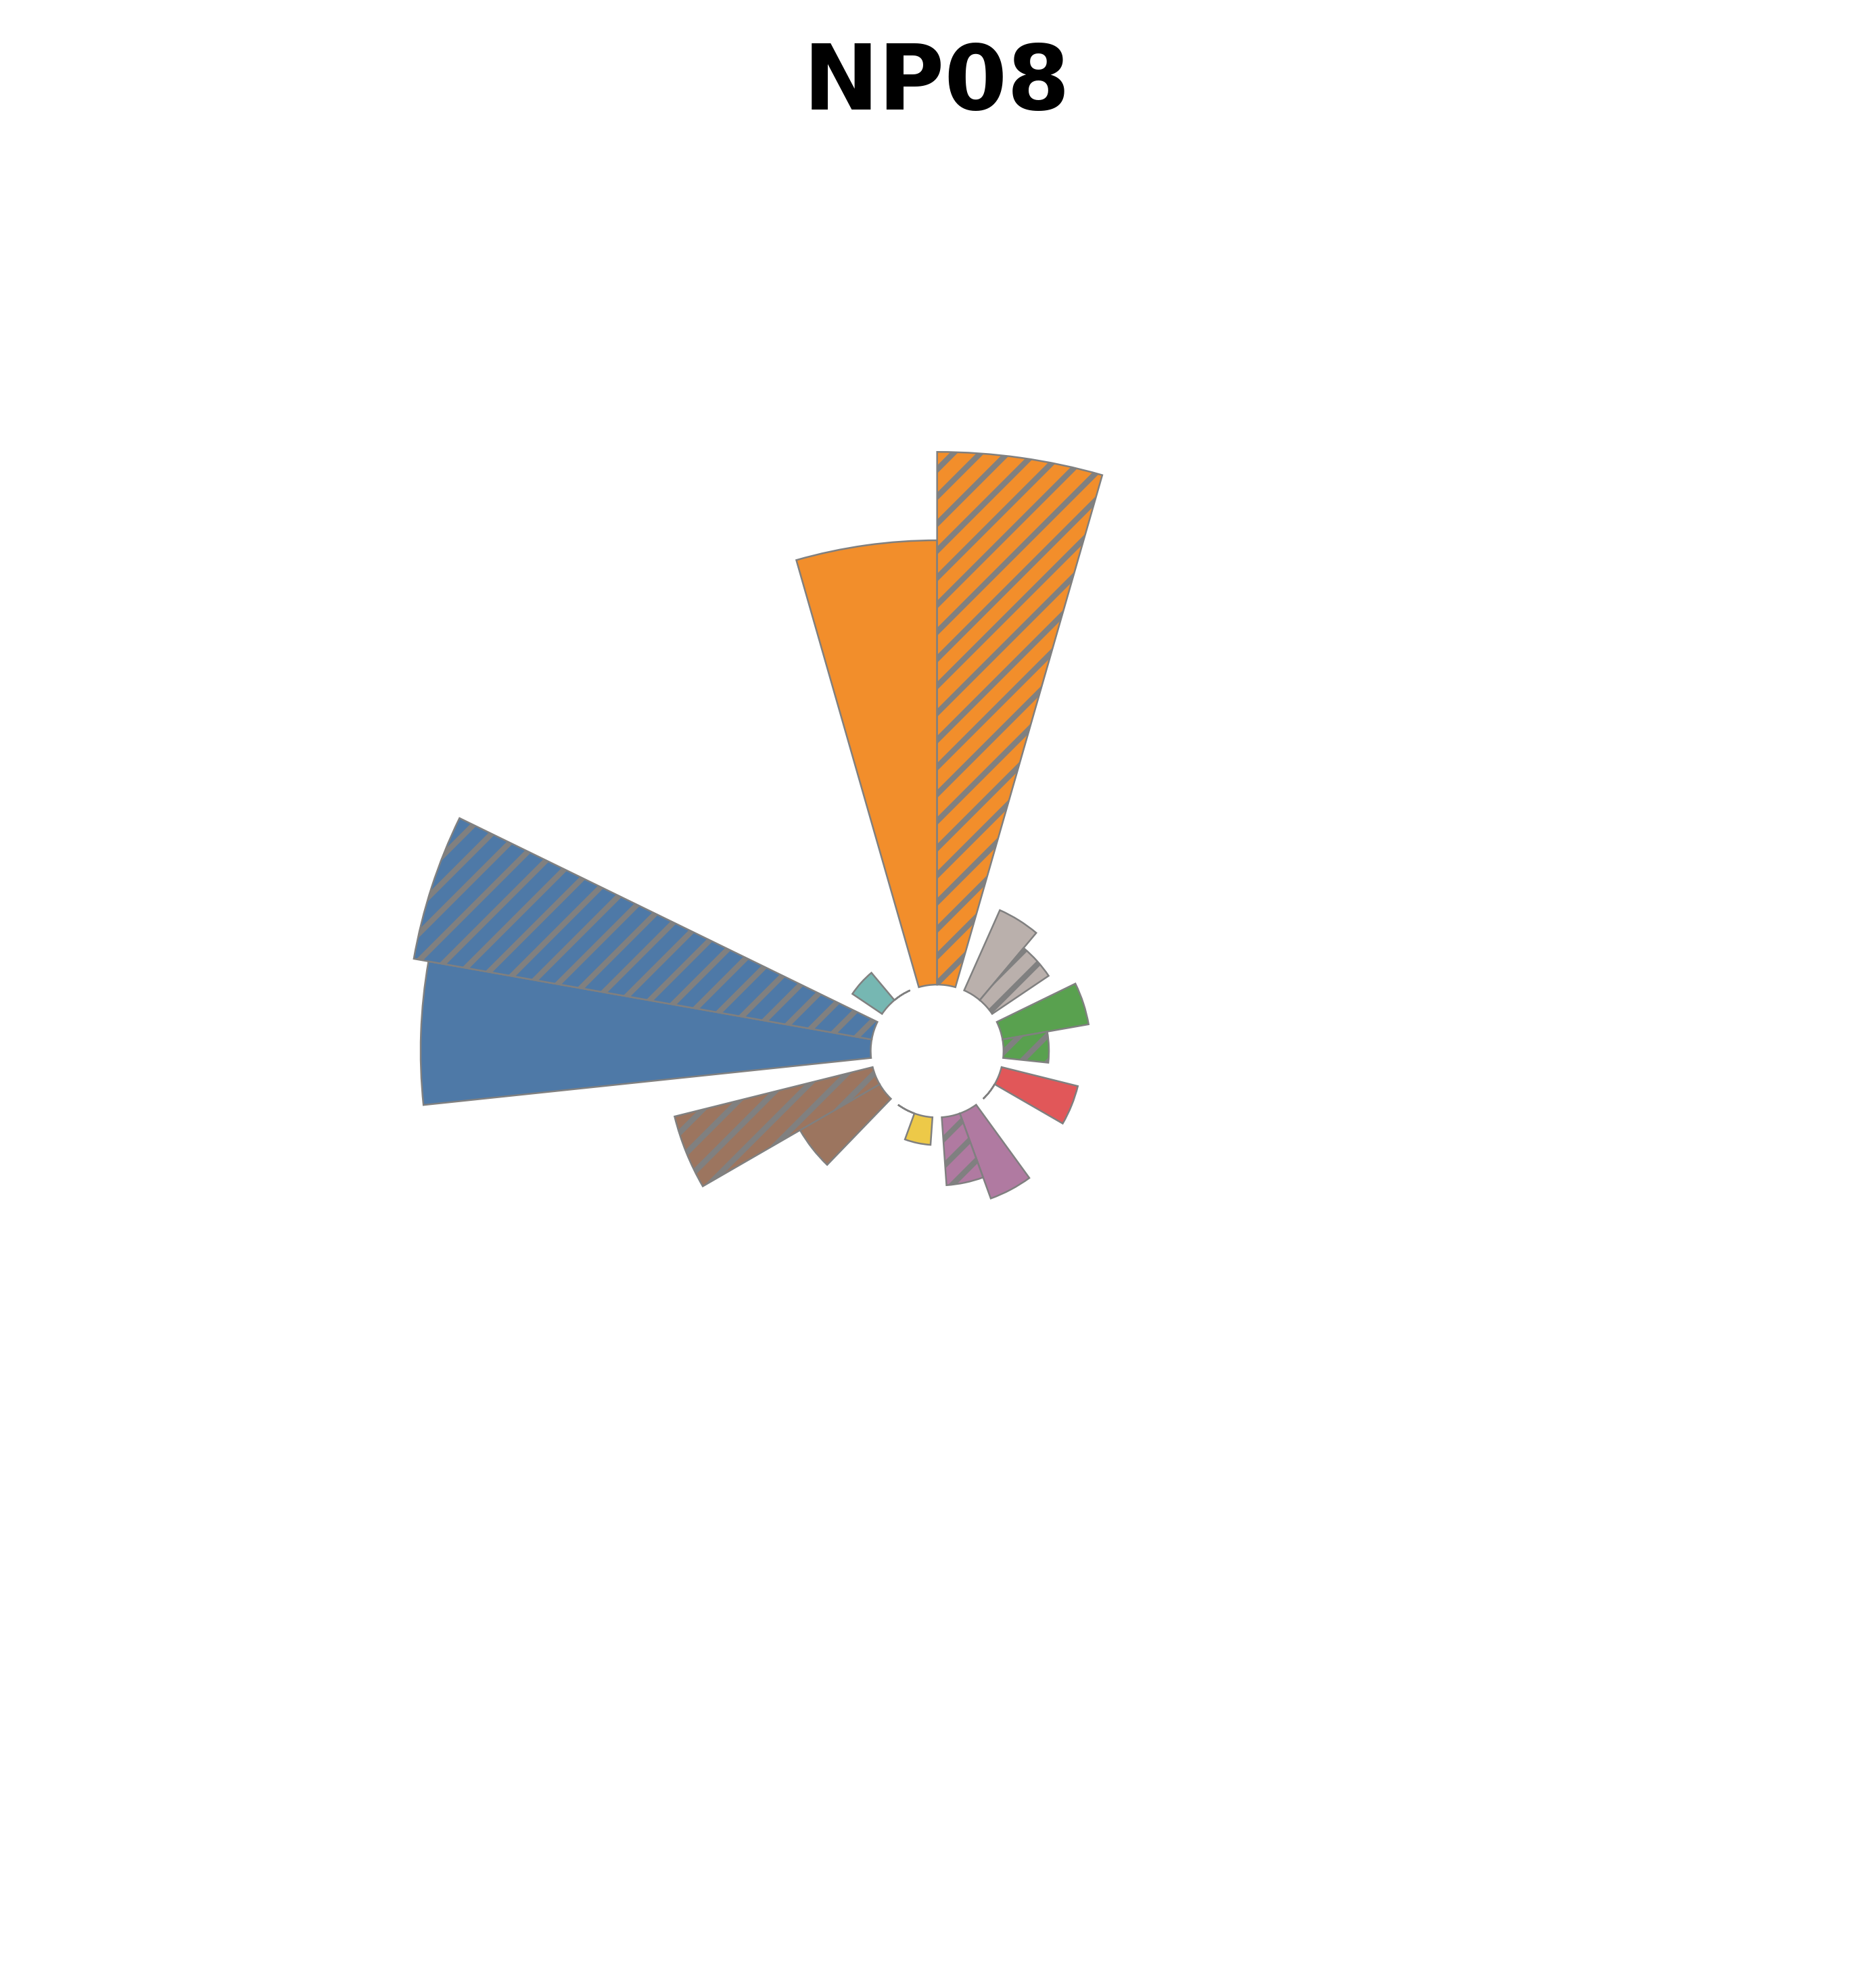

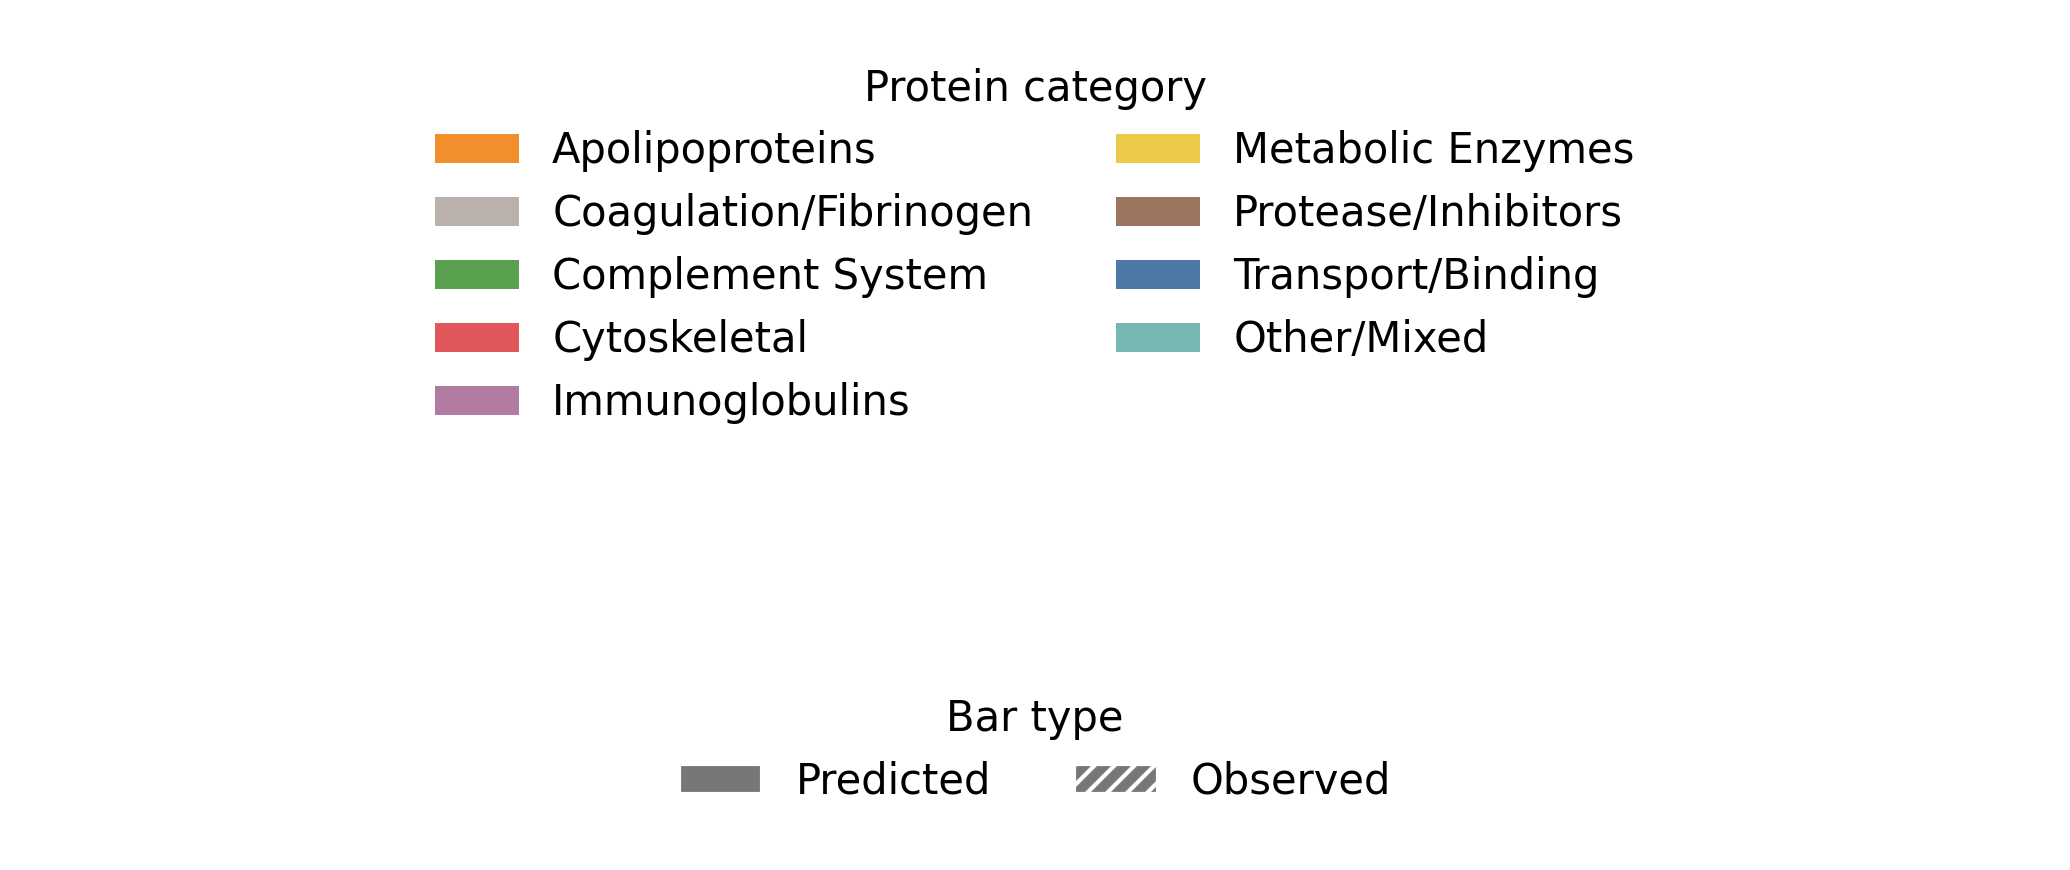

[saved] 8 NP plots
[saved] minimum display height = 2.0%
[saved] legend.png
[saved] external_validation_predicted_observed_percentages.csv


In [4]:
# ----------------------------------------------------------------
# 1) Category colors
# ----------------------------------------------------------------
TABLEAU10 = [
    "#4E79A7", "#59A14F", "#B07AA1", "#E15759", "#76B7B2",
    "#BAB0AC", "#F28E2B", "#9C755F", "#EDC948",
]

panel_ids_all = [c for c in OUT_COLS if c != "OTHER"]


def _cat_of_any(pid):
    # Match each protein to its functional category.
    name = id_to_name.get(pid, pid)

    if pid in id_to_cat:
        cat = id_to_cat[pid]
    elif name in id_to_cat:
        cat = id_to_cat[name]
    else:
        cat = "Other/Mixed"

    return cat if cat in CATEGORY_ORDER else "Other/Mixed"


# Count proteins in each category.
_counts = {c: 0 for c in CATEGORY_ORDER}

for pid in panel_ids_all:
    _counts[_cat_of_any(pid)] += 1


# More common categories receive colors first.
_ranked_cats = sorted(
    [c for c in CATEGORY_ORDER if _counts[c] > 0],
    key=lambda c: (-_counts[c], CATEGORY_ORDER.index(c)),
)

CAT_COLOR = {
    cat: TABLEAU10[i % len(TABLEAU10)]
    for i, cat in enumerate(_ranked_cats)
}

for c in CATEGORY_ORDER:
    CAT_COLOR.setdefault(c, "#CCCCCC")


# ----------------------------------------------------------------
# 2) Categories and bar angles
# ----------------------------------------------------------------
_cat_has_signal = {c: False for c in CATEGORY_ORDER}

for np_id in pie_data:
    for c in CATEGORY_ORDER:

        pred = pie_data[np_id]["predicted_category"].get(c, 0.0)
        obs = pie_data[np_id]["observed_category"].get(c, 0.0)

        if pred > 0 or obs > 0:
            _cat_has_signal[c] = True


BAR_CATS = [c for c in CATEGORY_ORDER if _cat_has_signal[c]]
N_BARS = len(BAR_CATS)

# Each category occupies one equal angular slot.
SLOT = 2 * np.pi / N_BARS

# Predicted and observed share the same category slot.
BAR_W = SLOT * 0.40

# These are the center angles of all category slots.
SLOT_CENTRE = np.arange(N_BARS) * SLOT

# Put predicted on the left and observed on the right.
PRED_ANG = SLOT_CENTRE - BAR_W / 2
OBS_ANG = SLOT_CENTRE + BAR_W / 2

# Start from 12 o'clock.
OFFSET = np.pi / 2


# ----------------------------------------------------------------
# 3) Shared radial scale
# ----------------------------------------------------------------
_max_pct = 0.0

for np_id in pie_data:
    for c in BAR_CATS:

        pred = pie_data[np_id]["predicted_category"].get(c, 0.0) * 100
        obs = pie_data[np_id]["observed_category"].get(c, 0.0) * 100

        _max_pct = max(_max_pct, pred, obs)


# Round the maximum value to the next 10%.
Y_MAX = float(np.ceil(_max_pct / 10) * 10)

# Negative radius creates the empty center.
Y_MIN = -Y_MAX * 0.08

# Small non-zero bars are displayed at least this high.
MIN_DISPLAY_PCT = 2.0


# ----------------------------------------------------------------
# 4) Draw one circular plot
# ----------------------------------------------------------------
def _draw_circular_bars(ax, pred_frac, obs_frac, title):

    # Convert fractions to real percentages.
    pred_v = np.array([
        pred_frac.get(c, 0.0) * 100
        for c in BAR_CATS
    ])

    obs_v = np.array([
        obs_frac.get(c, 0.0) * 100
        for c in BAR_CATS
    ])

    # Give small non-zero bars a minimum visible height.
    pred_plot = np.where(
        (pred_v > 0) & (pred_v < MIN_DISPLAY_PCT),
        MIN_DISPLAY_PCT,
        pred_v,
    )

    obs_plot = np.where(
        (obs_v > 0) & (obs_v < MIN_DISPLAY_PCT),
        MIN_DISPLAY_PCT,
        obs_v,
    )

    colors = [CAT_COLOR[c] for c in BAR_CATS]

    ax.set_theta_offset(OFFSET)
    ax.set_theta_direction(-1)
    ax.set_ylim(Y_MIN, Y_MAX)

    # Predicted composition uses solid bars.
    ax.bar(
        PRED_ANG,
        pred_plot,
        width=BAR_W,
        color=colors,
        edgecolor="grey",
        linewidth=0.3,
        zorder=3,
    )

    # Observed composition uses hatched bars.
    ax.bar(
        OBS_ANG,
        obs_plot,
        width=BAR_W,
        color=colors,
        edgecolor="grey",
        linewidth=0.3,
        hatch="/////",
        zorder=3,
    )

    ax.set_frame_on(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_title(
        title,
        fontsize=16,
        fontweight="bold",
        pad=8,
    )


# ----------------------------------------------------------------
# 5) Save each NP separately
# ----------------------------------------------------------------
SAVE_DIR = "external_validation_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

np_ids = list(pie_data.keys())


for i, np_id in enumerate(np_ids, start=1):

    label = f"NP{i:02d}"

    fig, ax = plt.subplots(
        figsize=(5, 5),
        dpi=600,
        subplot_kw={"projection": "polar"},
    )

    _draw_circular_bars(
        ax,
        pie_data[np_id]["predicted_category"],
        pie_data[np_id]["observed_category"],
        label,
    )

    fig.tight_layout()

    fig.savefig(
        os.path.join(SAVE_DIR, f"{label}.png"),
        dpi=600,
        bbox_inches="tight",
        transparent=True,
    )

    plt.show()
    plt.close(fig)


# ----------------------------------------------------------------
# 6) Save one shared legend
# ----------------------------------------------------------------
category_handles = [
    mpatches.Patch(
        facecolor=CAT_COLOR[c],
        edgecolor="none",
        label=c,
    )
    for c in BAR_CATS
]


bar_handles = [
    mpatches.Patch(
        facecolor="#777777",
        edgecolor="white",
        label="Predicted",
    ),

    mpatches.Patch(
        facecolor="#777777",
        edgecolor="white",
        hatch="/////",
        label="Observed",
    ),
]


fig, ax = plt.subplots(
    figsize=(7, 3),
    dpi=300,
)

ax.axis("off")


legend1 = ax.legend(
    handles=category_handles,
    title="Protein category",
    loc="upper center",
    ncol=2,
    frameon=False,
)

ax.add_artist(legend1)


ax.legend(
    handles=bar_handles,
    title="Bar type",
    loc="lower center",
    ncol=2,
    frameon=False,
)


fig.tight_layout()

fig.savefig(
    os.path.join(SAVE_DIR, "legend.png"),
    dpi=600,
    bbox_inches="tight",
    transparent=True,
)

plt.show()
plt.close(fig)


# ----------------------------------------------------------------
# 7) Save real predicted and observed percentages
# ----------------------------------------------------------------
rows = []


for i, np_id in enumerate(np_ids, start=1):

    label = f"NP{i:02d}"

    for c in BAR_CATS:

        # These are the real values, not the display heights.
        pred_pct = (
            pie_data[np_id]["predicted_category"].get(c, 0.0)
            * 100
        )

        obs_pct = (
            pie_data[np_id]["observed_category"].get(c, 0.0)
            * 100
        )

        rows.append({
            "NP": label,
            "Original_ID": np_id,
            "Category": c,
            "Predicted_percent": pred_pct,
            "Observed_percent": obs_pct,
        })


percentage_df = pd.DataFrame(rows)

percentage_df.to_csv(
    os.path.join(
        SAVE_DIR,
        "external_validation_predicted_observed_percentages.csv"
    ),
    index=False,
)


print(f"[saved] {len(np_ids)} NP plots")
print(f"[saved] minimum display height = {MIN_DISPLAY_PCT}%")
print("[saved] legend.png")
print("[saved] external_validation_predicted_observed_percentages.csv")